
**1. Data Preprocessing:**

In [1]:
import pandas as pd

# 1. Read the CSV files
confirmed_cases_df = pd.read_csv("time_series_covid19_confirmed_US.csv")
deaths_df = pd.read_csv("time_series_covid19_deaths_US.csv")

print ('The two csv files have been successfully read ')



The two csv files have been successfully read 


In [2]:
confirmed_cases_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,19732,19759,19759,19759,19759,19759,19759,19759,19790,19790
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,69641,69767,69767,69767,69767,69767,69767,69767,69860,69860
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,7451,7474,7474,7474,7474,7474,7474,7474,7485,7485
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,8067,8087,8087,8087,8087,8087,8087,8087,8091,8091
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,18616,18673,18673,18673,18673,18673,18673,18673,18704,18704


In [3]:
deaths_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,230,232,232,232,232,232,232,232,232,232
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,724,726,726,726,726,726,726,726,727,727
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,103,103,103,103,103,103,103,103,103,103
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,109,109,109,109,109,109,109,109,109,109
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,261,261,261,261,261,261,261,261,261,261


In [4]:
# Get all date columns (everything after the 4 identifier columns)
id_cols = ["Combined_Key", "Admin2", "Province_State", "Country_Region"]
date_cols = [col for col in confirmed_cases_df.columns if col not in id_cols]

confirmed_cases_df = confirmed_cases_df[id_cols + date_cols]
deaths_df = deaths_df[id_cols + date_cols]

Combined_Key is simply a joined location label. It combines the other location columns into one readable string.Its literally just, County + State + Country joined with commas.
-------------------------------------------------------------------------------

Where does it come from? It was created by Johns Hopkins University (who published this dataset) by simply concatenating those three columns together — it wasn't collected from any source, they just built it to give each row a unique, human-readable location ID.

--------------------------------------------------------------------------------
Why is it useful? Instead of always combining 3 columns to identify a location, we can just use Combined_Key as a single unique identifier for each row.

# 1.2 SELECTING ESSENTIAL COLUMNS

In [5]:
# ── CELL 2: Select Essential Columns ────────────────────────────

# Step 1: Define the location columns we want to keep
ID_COLS = ["Combined_Key", "Admin2", "Province_State", "Country_Region"]
# Combined_Key  = full location name e.g. "Autauga, Alabama, US"
# Admin2        = county name e.g. "Autauga"
# Province_State= state name e.g. "Alabama"
# Country_Region= country name e.g. "US"

# Step 2: Define the date range we care about
FIRST_DATE = "1/22/20"   # January 22, 2020 — when data collection started
LAST_DATE  = "3/9/23"    # March 9, 2023 — when data collection ended

# Step 3: Get all column names from the dataset as a simple list
all_cols = confirmed_cases_df.columns.tolist()
# This gives us: ["Combined_Key", "Admin2", ..., "1/22/20", "1/23/20", ..., "3/9/23"]

# Step 4: From that list, grab only the date columns
# .index() finds the position of a value in a list
# For example: all_cols.index("1/22/20") might return position 10
# We slice from that position to the last date position (+1 to include the last date)
date_cols = all_cols[all_cols.index(FIRST_DATE) : all_cols.index(LAST_DATE) + 1]
# Result: ["1/22/20", "1/23/20", "1/24/20", ... , "3/9/23"]

# Step 5: Combine location columns + date columns into one final list
keep_cols = ID_COLS + date_cols
# Result: ["Combined_Key", "Admin2", ..., "1/22/20", "1/23/20", ..., "3/9/23"]

# Step 6: Apply the selection to both datasets — keeping only what we need
confirmed_cases_df = confirmed_cases_df[keep_cols]
deaths_df          = deaths_df[keep_cols]

# Summary of what we did
print(f"✅ Columns selected: {len(ID_COLS)} ID columns + {len(date_cols)} date columns")
print(f"📅 Date range: {FIRST_DATE} to {LAST_DATE}")
print(f"📊 Total columns kept: {len(keep_cols)}")

✅ Columns selected: 4 ID columns + 1143 date columns
📅 Date range: 1/22/20 to 3/9/23
📊 Total columns kept: 1147


## 1.3 Exploring the data (descriptive statistics, visualizations)

In [6]:
# CELL 3: Descriptive Statistics

# Get all date columns
date_cols = [col for col in confirmed_cases_df.columns if "/" in col]

# Overall totals (last date = cumulative total)
total_cases  = confirmed_cases_df[date_cols[-1]].sum()
total_deaths = deaths_df[date_cols[-1]].sum()
death_rate   = (total_deaths / total_cases) * 100

print("=== OVERALL TOTALS ===")
print(f"Total Cases  : {total_cases:,}")
print(f"Total Deaths : {total_deaths:,}")
print(f"Death Rate   : {death_rate:.2f}%")
print(f"Days Tracked : {len(date_cols)}")


=== OVERALL TOTALS ===
Total Cases  : 103,802,702
Total Deaths : 1,123,836
Death Rate   : 1.08%
Days Tracked : 1143


/tmp/ipykernel_21877/963901661.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  x_axis = pd.to_datetime(sampled_dates)


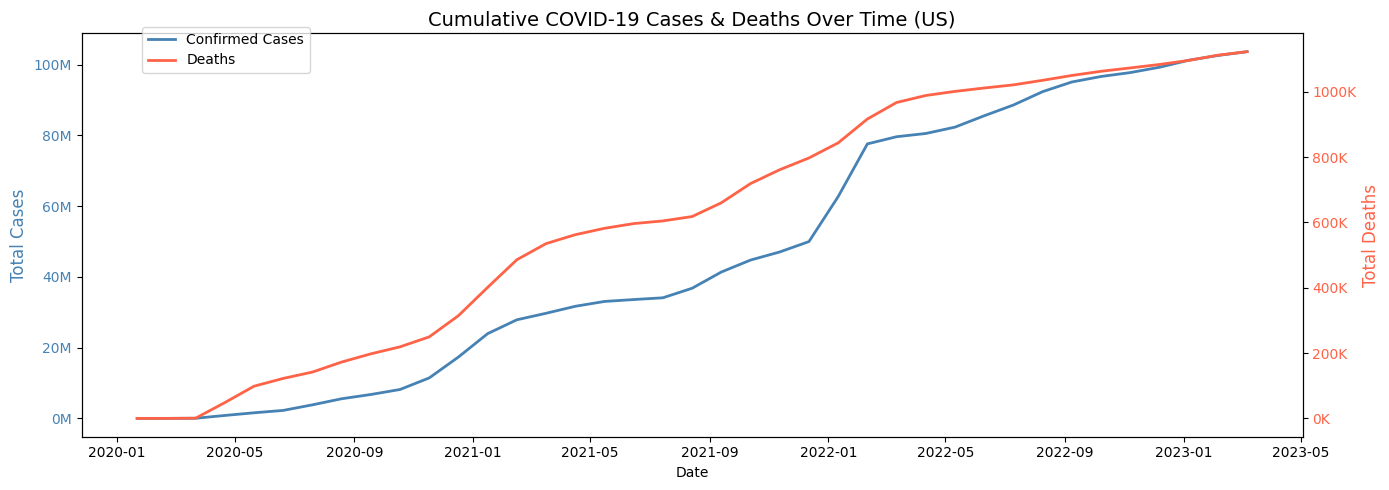

In [7]:
#  CELL 4: Visualizations

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Get all date columns
date_cols = [col for col in confirmed_cases_df.columns if "/" in col]

# Sample every 30 days so the charts are not overcrowded
sampled_dates = date_cols[::30]

# Convert sampled date strings to proper datetime for clean x-axis labels
x_axis = pd.to_datetime(sampled_dates)

# ── VISUAL 1: Cumulative Cases & Deaths Over Time (Line Chart) ──

fig, ax1 = plt.subplots(figsize=(14, 5))

# Sum all counties per day to get the US total for each date
us_cases  = confirmed_cases_df[sampled_dates].sum()
us_deaths = deaths_df[sampled_dates].sum()

# Plot cases on the left y-axis
ax1.plot(x_axis, us_cases.values, color="steelblue", linewidth=2, label="Confirmed Cases")
ax1.set_ylabel("Total Cases", color="steelblue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

# Create a second y-axis on the right side for deaths
ax2 = ax1.twinx()
ax2.plot(x_axis, us_deaths.values, color="tomato", linewidth=2, label="Deaths")
ax2.set_ylabel("Total Deaths", color="tomato", fontsize=12)
ax2.tick_params(axis="y", labelcolor="tomato")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

ax1.set_title("Cumulative COVID-19 Cases & Deaths Over Time (US)", fontsize=14)
ax1.set_xlabel("Date")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig("visual1_cases_deaths_over_time.png", dpi=150, bbox_inches="tight")
plt.show()



# 1.4 HANDLING MISSING VALUES

In [8]:
print(" Missing values in Confirmed Cases")
confirmed_missing = confirmed_cases_df.isnull().sum()
print(confirmed_missing[confirmed_missing > 0] if confirmed_missing.any() else "No missing values ")

print(" Missing values in Deaths ")
death_missing = deaths_df.isnull().sum()
print(death_missing[death_missing > 0] if death_missing.any() else "No missing values ")

 Missing values in Confirmed Cases
Admin2    6
dtype: int64
 Missing values in Deaths 
Admin2    6
dtype: int64


In [9]:
# Replace missing Admin2 with "Unknown"
confirmed_cases_df["Admin2"] = confirmed_cases_df["Admin2"].fillna("Unknown")
deaths_df["Admin2"]   = deaths_df["Admin2"].fillna("Unknown")

print(" Missing Admin2 filled with Unknown")
print(confirmed_cases_df["Admin2"].isnull().sum())

 Missing Admin2 filled with Unknown
0


We use "Unknown" because these rows are real locations with real COVID data we don't want to lose them, but we also can't make up a county name that doesn't exist.Fill with "Unknown" — we keep the data and signal that "this place simply doesn't have a county"

In [10]:
# Explore data (descriptive statistics, visualizations)
confirmed_cases_df.describe()
deaths_df.describe()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
count,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,...,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000
mean,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,...,335.103830,335.397068,335.624776,335.776481,335.778576,335.767205,335.781269,335.881508,336.099940,336.276481
std,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,...,1103.909631,1104.435933,1105.572242,1105.748480,1105.751727,1105.746239,1105.772895,1105.924446,1106.230834,1107.369648
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,39.000000,39.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,245.750000,245.750000,245.750000,246.000000,246.000000,246.000000,246.000000,246.750000,246.750000,246.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,35366.000000,35366.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35545.000000


In [11]:
# Check data types and consistency
#  CELL 5: Check Data Types & Consistency
# Convert date columns to integers (whole numbers, no decimals)
confirmed_cases_df[date_cols] = confirmed_cases_df[date_cols].astype(int)
deaths_df[date_cols]    = deaths_df[date_cols].astype(int)

print(" Data types ")
print(confirmed_cases_df.dtypes[:4])

 Data types 
Combined_Key      object
Admin2            object
Province_State    object
Country_Region    object
dtype: object


In [12]:
# A death count should never exceed confirmed cases — flag if it does
inconsistent = (deaths_df[date_cols].values > confirmed_cases_df[date_cols].values).sum()
print(f"\nInconsistent entries (deaths > confirmed): {inconsistent}")
print("(These come from known reporting lags in the raw data)")


Inconsistent entries (deaths > confirmed): 7565
(These come from known reporting lags in the raw data)


In [13]:
# Merge files if necessary (based on Combined_Key)
# CELL 5: Merge the Two Datasets

# Merge confirmed cases and deaths into one single dataset
# We use "Combined_Key" as the linking column — it uniquely identifies each location
# Think of it like a ZIP code that matches rows from both datasets together

merged_df = confirmed_cases_df.merge(
    deaths_df,
    on       = "Combined_Key",   # match rows where Combined_Key is the same
    how      = "inner",          # only keep rows that exist in BOTH datasets
    suffixes = ("_cases", "_deaths")  # rename duplicate columns to avoid confusion
                                      # e.g. "1/22/20" becomes "1/22/20_cases" and "1/22/20_deaths"
)

# Check the result
print(f"Confirmed Cases shape : {confirmed_cases_df.shape}")
print(f"Deaths shape          : {deaths_df.shape}")
print(f"Merged shape          : {merged_df.shape}")
print(f"\nFirst few columns: {list(merged_df.columns[:8])}")
#```

#**What `how="inner"` means simply:**

#Think of two lists:
#```
#confirmed_cases_df:   Location A, Location B, Location C
#deaths_df:            Location A, Location B, Location D
#                                                   ↑ different!
#inner merge result:   Location A, Location B only
 #                     (only keeps what exists in BOTH)

Confirmed Cases shape : (3342, 1147)
Deaths shape          : (3342, 1147)
Merged shape          : (3342, 2293)

First few columns: ['Combined_Key', 'Admin2_cases', 'Province_State_cases', 'Country_Region_cases', '1/22/20_cases', '1/23/20_cases', '1/24/20_cases', '1/25/20_cases']


# **2. Descriptive Analysis:**

# **National Level:**

In [14]:
# Aggregate case and death data by date
national_confirmed_cases = confirmed_cases_df.groupby("Combined_Key")[list(confirmed_cases_df.filter(like="/")[1:])].sum()  # Select date columns
national_deaths = deaths_df.groupby("Combined_Key")[list(deaths_df.filter(like="/")[1:])].sum()  # Select date columns

# Visualize national trends (line plots, heatmaps)
#...  # Use matplotlib or seaborn for visualizations

# Calculate national rates of change
#...

# Figure 1 — National cumulative trend (line plot)

In [15]:
# First, I need to import the tools/libraries I will use
# pandas helps me work with tables of data
import pandas as pd

# numpy helps me do math
import numpy as np

# matplotlib is what I use to draw charts
import matplotlib.pyplot as plt

# this helps me format dates nicely on the x-axis
import matplotlib.dates as mdates

# seaborn makes prettier charts, especially heatmaps
import seaborn as sns

# this just hides annoying warning messages
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# STEP 1: Get only the date columns from my data
# -------------------------------------------------------
# The date columns all have a "/" in them like "1/22/20"
# So I will loop through all columns and keep only those with "/"

date_columns = []  # start with an empty list

for column_name in national_confirmed_cases.columns:
    if "/" in column_name:  # check if this column is a date
        date_columns.append(column_name)  # if yes, add it to my list

# now date_columns has all the date column names like ['1/22/20', '1/23/20', ...]
print("Number of date columns found:", len(date_columns))
print("First date:", date_columns[0])
print("Last date:", date_columns[-1])

# -------------------------------------------------------
# STEP 2: Flip the table so dates are rows, not columns
# -------------------------------------------------------
# Right now: rows = locations, columns = dates
# I want:    rows = dates,     columns = locations
# The .T command flips (transposes) the table

cases_flipped  = national_confirmed_cases[date_columns].T
deaths_flipped = national_deaths[date_columns].T

# make a copy so I don't accidentally change the original
cases_flipped  = cases_flipped.copy()
deaths_flipped = deaths_flipped.copy()

# -------------------------------------------------------
# STEP 3: Convert date text into real date objects
# -------------------------------------------------------
# Right now the dates are just text like "1/22/20"
# I want Python to understand them as actual dates

cases_flipped.index  = pd.to_datetime(cases_flipped.index)
deaths_flipped.index = pd.to_datetime(deaths_flipped.index)

print("Data is ready!")
print("Date range:", cases_flipped.index[0], "to", cases_flipped.index[-1])

# -------------------------------------------------------
# STEP 4: Add up all locations to get the national total
# -------------------------------------------------------
# axis=1 means "add across all columns (locations)" for each row (date)

national_cases_per_day  = cases_flipped.sum(axis=1)
national_deaths_per_day = deaths_flipped.sum(axis=1)

print("Total cases by the last date:", national_cases_per_day[-1])

Number of date columns found: 1143
First date: 1/22/20
Last date: 3/9/23
Data is ready!
Date range: 2020-01-22 00:00:00 to 2023-03-09 00:00:00
Total cases by the last date: 103802702


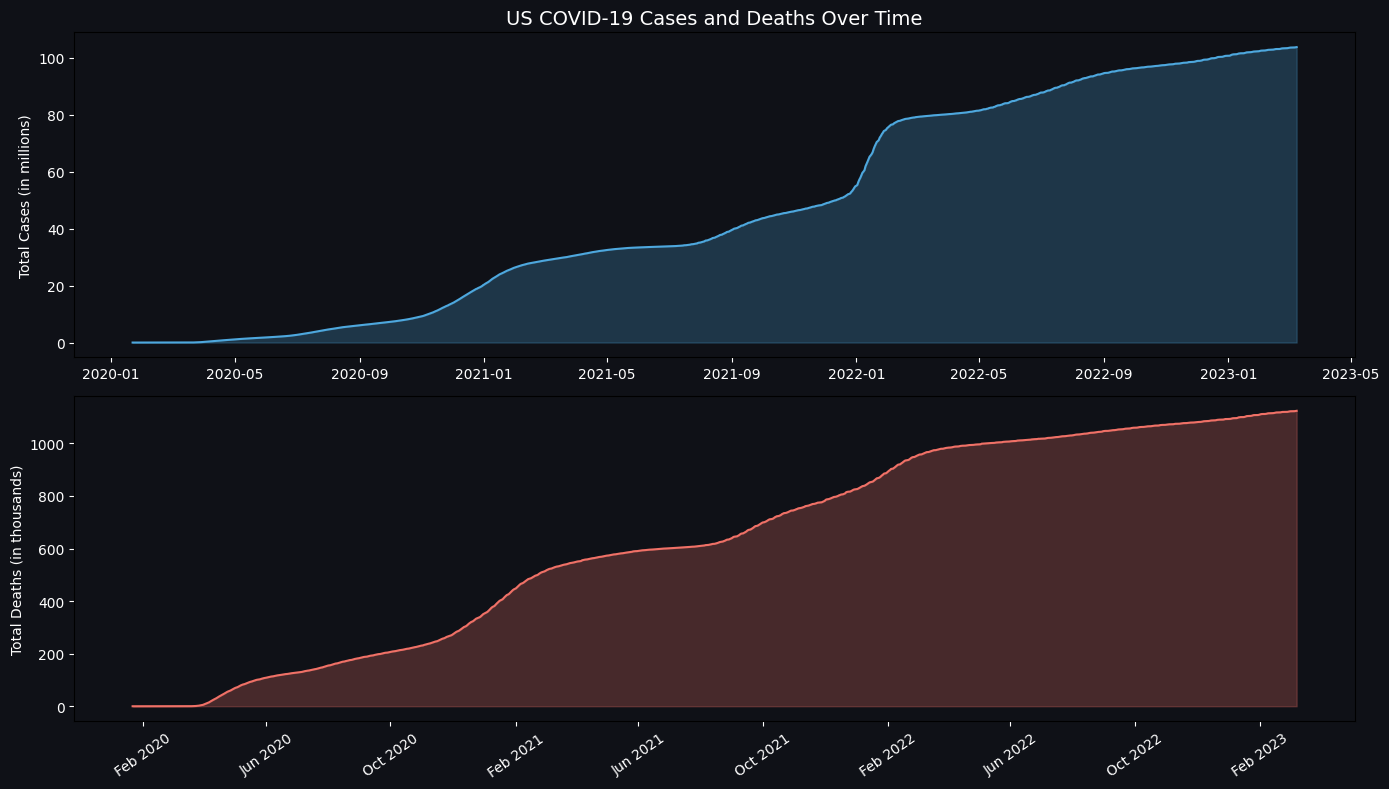

Figure 1 saved!


In [16]:
# -------------------------------------------------------
# FIGURE 1: Show national cases and deaths as line charts
# -------------------------------------------------------

# Create a figure with 2 charts stacked on top of each other
# 2 rows, 1 column, figure size is 14 wide and 8 tall (in inches)
my_figure, (top_chart, bottom_chart) = plt.subplots(2, 1, figsize=(14, 8))

# Make the background dark
my_figure.patch.set_facecolor('#0f1117')
top_chart.set_facecolor('#0f1117')
bottom_chart.set_facecolor('#0f1117')

# --- Draw the top chart: Confirmed Cases ---
# Divide by 1,000,000 so the y-axis shows millions instead of huge numbers
cases_in_millions = national_cases_per_day.values / 1000000

top_chart.plot(national_cases_per_day.index, cases_in_millions,
               color='#4ea8de',   # blue color
               linewidth=1.5)

# Fill the area under the line with a see-through blue color
# alpha=0.25 means 25% solid (75% see-through)
top_chart.fill_between(national_cases_per_day.index, cases_in_millions,
                        alpha=0.25, color='#4ea8de')

top_chart.set_ylabel('Total Cases (in millions)', color='white')
top_chart.set_title('US COVID-19 Cases and Deaths Over Time', color='white', fontsize=14)
top_chart.tick_params(colors='white')

# --- Draw the bottom chart: Deaths ---
deaths_in_thousands = national_deaths_per_day.values / 1000

bottom_chart.plot(national_deaths_per_day.index, deaths_in_thousands,
                  color='#f07167',   # red/orange color
                  linewidth=1.5)

bottom_chart.fill_between(national_deaths_per_day.index, deaths_in_thousands,
                           alpha=0.25, color='#f07167')

bottom_chart.set_ylabel('Total Deaths (in thousands)', color='white')
bottom_chart.tick_params(colors='white')

# Make the date labels look nice: show "Jan 2021" instead of "2021-01-01"
date_format = mdates.DateFormatter('%b %Y')
bottom_chart.xaxis.set_major_formatter(date_format)

# Only show a date label every 4 months so it doesn't get crowded
bottom_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))

plt.xticks(rotation=35, color='white')
plt.tight_layout()   # automatically fix any overlapping labels
plt.savefig('fig1_national_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Figure 1 saved!")

# Figure 2 — Daily new cases with 7-day average

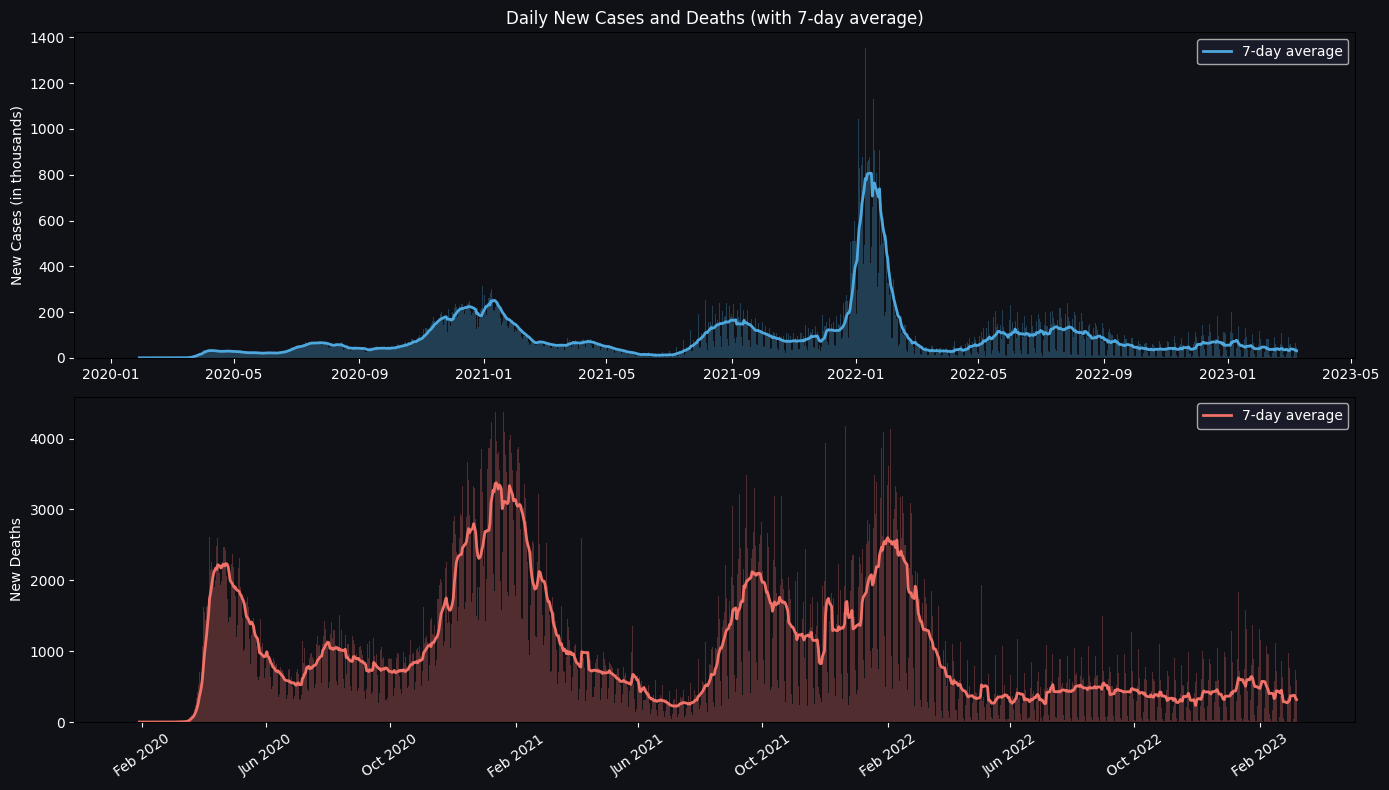

Figure 2 saved!


In [17]:
# FIGURE 2: How many NEW cases were reported each day?

# .diff() subtracts yesterday's total from today's total
# This turns the running total into daily NEW cases
daily_new_cases  = national_cases_per_day.diff()
daily_new_deaths = national_deaths_per_day.diff()

# Sometimes the data has small negative numbers due to corrections
# clip(lower=0) replaces any negative numbers with 0
daily_new_cases  = daily_new_cases.clip(lower=0)
daily_new_deaths = daily_new_deaths.clip(lower=0)

# Calculate a 7-day average to smooth out the bumpy daily data
# rolling(7) looks at the last 7 days, .mean() averages them
smoothed_cases  = daily_new_cases.rolling(7).mean()
smoothed_deaths = daily_new_deaths.rolling(7).mean()

#  Drawing the charts
my_figure, (top_chart, bottom_chart) = plt.subplots(2, 1, figsize=(14, 8))
my_figure.patch.set_facecolor('#0f1117')
top_chart.set_facecolor('#0f1117')
bottom_chart.set_facecolor('#0f1117')

# Top chart: daily new cases as bars + smooth line on top
new_cases_in_thousands = daily_new_cases.values / 1000

top_chart.bar(daily_new_cases.index,
              new_cases_in_thousands,
              color='#4ea8de',
              alpha=0.3,    # make bars see-through so the line shows through
              width=1)      # each bar is 1 day wide

top_chart.plot(smoothed_cases.index,
               smoothed_cases.values / 1000,
               color='#4ea8de',
               linewidth=2,
               label='7-day average')

top_chart.set_ylabel('New Cases (in thousands)', color='white')
top_chart.set_title('Daily New Cases and Deaths (with 7-day average)', color='white')
top_chart.legend(facecolor='#1e1e2e', labelcolor='white')
top_chart.tick_params(colors='white')

# Bottom chart: daily new deaths
bottom_chart.bar(daily_new_deaths.index,
                 daily_new_deaths.values,
                 color='#f07167',
                 alpha=0.3,
                 width=1)

bottom_chart.plot(smoothed_deaths.index,
                  smoothed_deaths.values,
                  color='#f07167',
                  linewidth=2,
                  label='7-day average')

bottom_chart.set_ylabel('New Deaths', color='white')
bottom_chart.legend(facecolor='#1e1e2e', labelcolor='white')
bottom_chart.tick_params(colors='white')
bottom_chart.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
bottom_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

plt.tight_layout()
plt.savefig('fig2_daily_new.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Figure 2 saved!")

# Figure 3 — Top 10 Regions Line Plot

Top 10 regions are: ['Los Angeles, California, US', 'Miami-Dade, Florida, US', 'Cook, Illinois, US', 'Maricopa, Arizona, US', 'Harris, Texas, US', 'San Diego, California, US', 'Kings, New York, US', 'Queens, New York, US', 'Orange, California, US', 'Riverside, California, US']


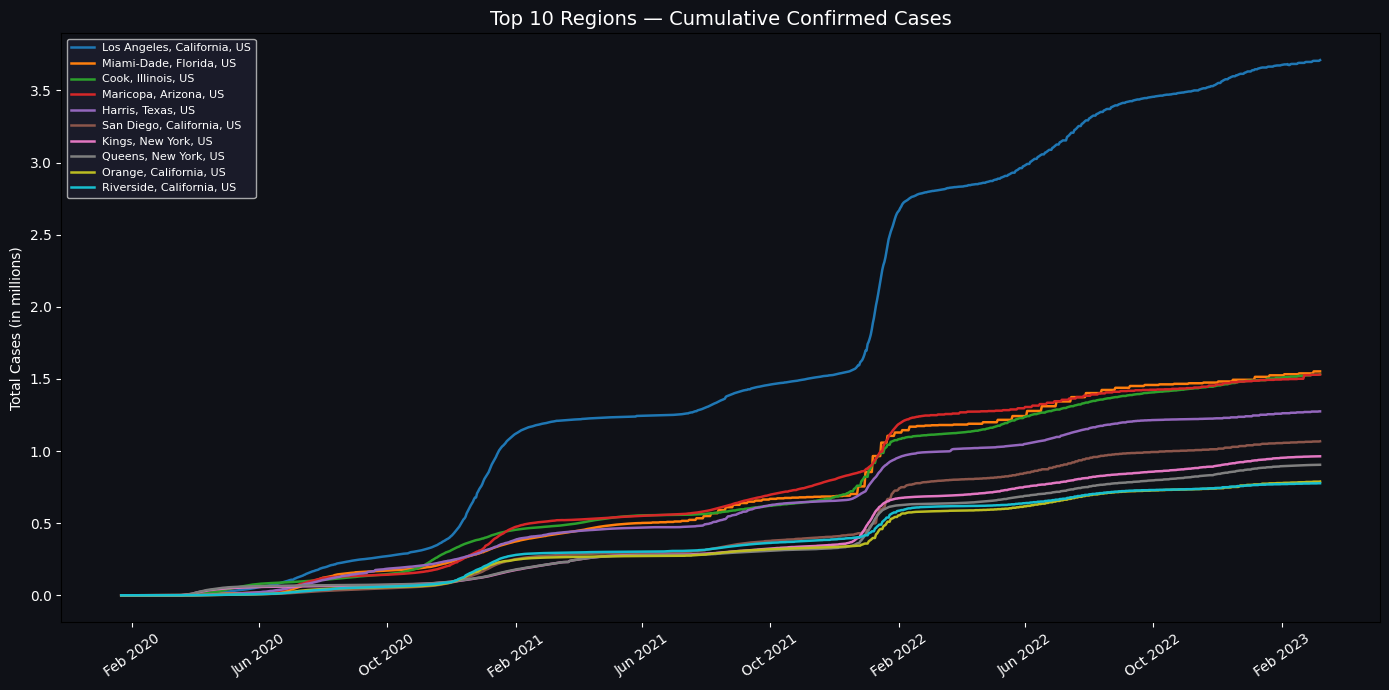

In [18]:

# FIGURE 3: Compare the top 10 regions on one chart

# Find the total cases for each region (look at the last row = most recent date)
total_per_region = cases_flipped.iloc[-1]   # iloc[-1] = last row

# Sort from highest to lowest and keep only the top 10
top_10_regions = total_per_region.sort_values(ascending=False).head(10)

# Get just the names of those top 10 regions
top_10_names = top_10_regions.index.tolist()

print("Top 10 regions are:", top_10_names)

# Pick 10 different colors so each region has its own color
ten_colors = sns.color_palette('tab10', 10)

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# Loop through each region and draw one line per region
for i in range(len(top_10_names)):
    region_name  = top_10_names[i]
    region_color = ten_colors[i]

    # Get this region's data and convert to millions
    region_data = cases_flipped[region_name] / 1000000

    my_chart.plot(region_data.index,
                  region_data.values,
                  color=region_color,
                  linewidth=1.8,
                  label=region_name)

my_chart.set_title('Top 10 Regions — Cumulative Confirmed Cases', color='white', fontsize=14)
my_chart.set_ylabel('Total Cases (in millions)', color='white')
my_chart.tick_params(colors='white')
my_chart.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('fig3_top10_regions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Figure 4 — Monthly new cases heatmap

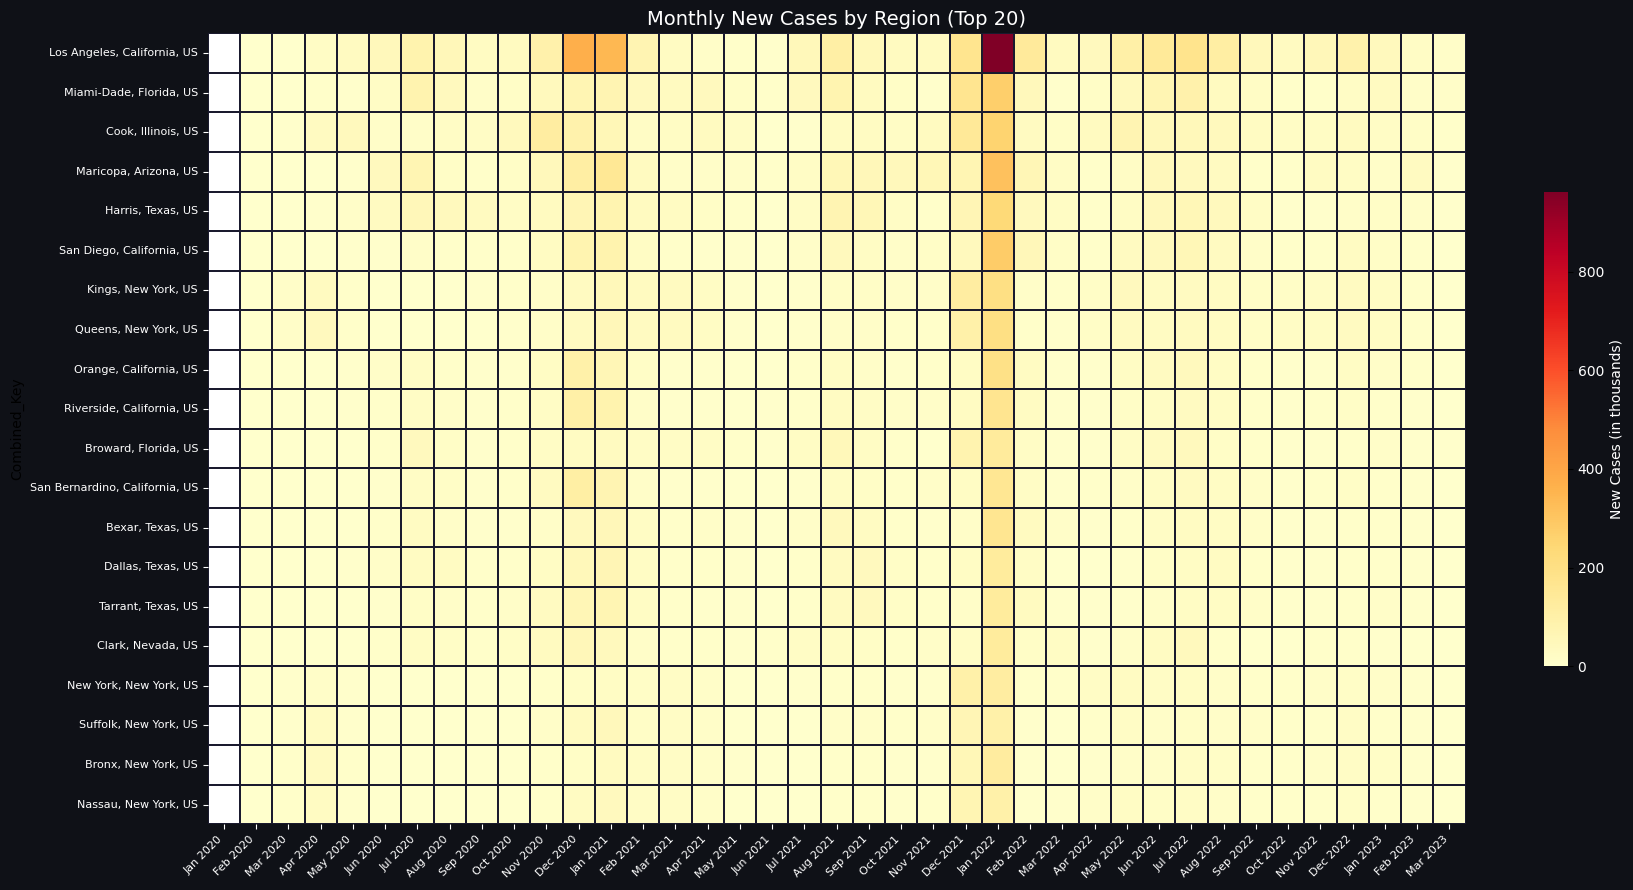

In [19]:

# FIGURE 4: Heatmap showing new cases per month per region


# resample('ME') groups the daily data into months
# .last() picks the last value in each month (the end-of-month total)
monthly_totals = cases_flipped.resample('ME').last()

# Now get new cases each month (subtract previous month from current month)
monthly_new_cases = monthly_totals.diff()

# Remove any negative values
monthly_new_cases = monthly_new_cases.clip(lower=0)

# Keep only the top 20 regions so the heatmap isn't too crowded
total_per_region = cases_flipped.iloc[-1]
top_20_names     = total_per_region.sort_values(ascending=False).head(20).index

# Filter to just the top 20 regions
heatmap_data = monthly_new_cases[top_20_names]

# Flip the table: regions as rows, months as columns
# This is what seaborn heatmap expects
heatmap_data = heatmap_data.T

# Convert to thousands so numbers are easier to read
heatmap_data = heatmap_data / 1000

# Create nice date labels like "Jan 2022"
date_labels = []
for date in heatmap_data.columns:
    label = date.strftime('%b %Y')   # strftime converts date to text
    date_labels.append(label)

# --- Draw the heatmap ---
my_figure, my_chart = plt.subplots(figsize=(18, 9))
my_figure.patch.set_facecolor('#0f1117')

sns.heatmap(
    heatmap_data,
    ax=my_chart,
    cmap='YlOrRd',           # color scale: yellow=low, orange=medium, red=high
    linewidths=0.3,           # thin lines between each cell
    linecolor='#1a1a2e',
    xticklabels=date_labels,  # use the nice date labels I made above
    cbar_kws={'label': 'New Cases (in thousands)', 'shrink': 0.6}
)

my_chart.set_title('Monthly New Cases by Region (Top 20)', color='white', fontsize=14)
my_chart.tick_params(colors='white', labelsize=8)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

# Fix the color bar labels
color_bar = my_chart.collections[0].colorbar
color_bar.ax.tick_params(labelcolor='white')
color_bar.set_label('New Cases (in thousands)', color='white')

plt.tight_layout()
plt.savefig('fig4_heatmap_monthly.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Figure 5 — Weekly growth rate heatmap

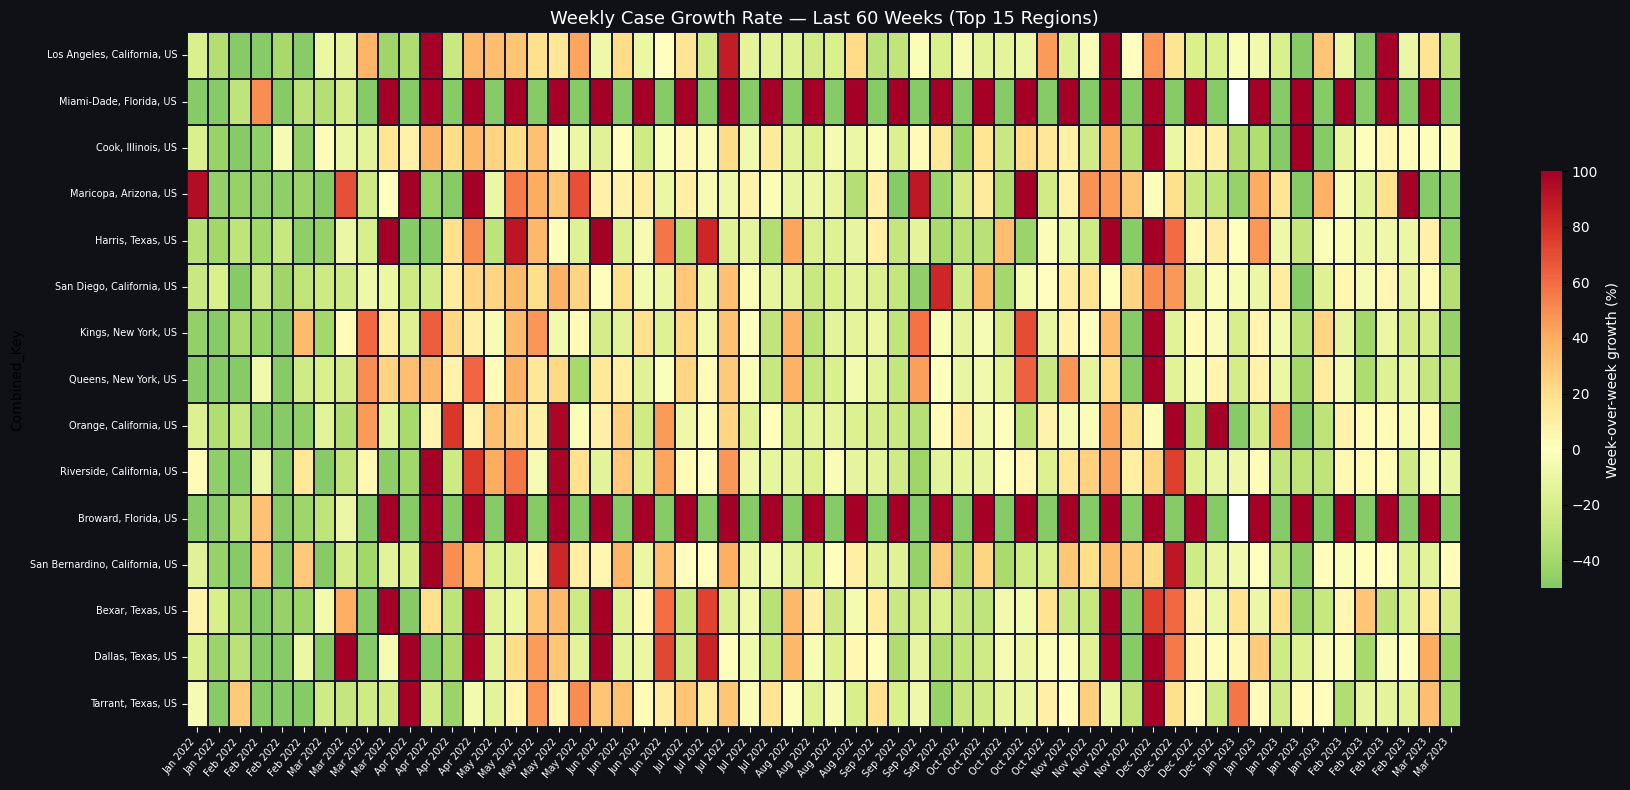

In [20]:
# -------------------------------------------------------
# FIGURE 5: How fast was each region growing week by week?
# -------------------------------------------------------

# Collapse daily data into weekly totals
# resample('W') groups by week, .last() takes the last day of each week
weekly_totals = cases_flipped.resample('W').last()

# Get new cases each week
weekly_new_cases = weekly_totals.diff()
weekly_new_cases = weekly_new_cases.clip(lower=0)

# Calculate how much the new cases grew compared to last week
# pct_change() = (this week - last week) / last week
# Multiply by 100 to turn it into a percentage
weekly_growth = weekly_new_cases.pct_change() * 100

# clip(-100, 500) removes extreme outliers that would break the color scale
weekly_growth = weekly_growth.clip(-100, 500)

# Keep only top 15 regions and last 60 weeks
total_per_region  = cases_flipped.iloc[-1]
top_15_names      = total_per_region.sort_values(ascending=False).head(15).index

growth_top15      = weekly_growth[top_15_names]
last_60_weeks     = growth_top15.iloc[-60:]   # iloc[-60:] = last 60 rows

# Flip so regions are rows, weeks are columns
growth_chart_data = last_60_weeks.T

# Create date labels for the columns
week_labels = []
for date in growth_chart_data.columns:
    week_labels.append(date.strftime('%b %Y'))

# --- Draw the heatmap ---
my_figure, my_chart = plt.subplots(figsize=(18, 8))
my_figure.patch.set_facecolor('#0f1117')

sns.heatmap(
    growth_chart_data,
    ax=my_chart,
    cmap='RdYlGn_r',     # Red = high growth (bad), Green = low/negative growth (good)
    center=0,             # 0% growth gets the middle color (yellow)
    vmin=-50,             # color scale starts at -50%
    vmax=100,             # color scale ends at +100%
    linewidths=0.2,
    linecolor='#1a1a2e',
    xticklabels=week_labels,
    cbar_kws={'label': 'Week-over-week growth (%)', 'shrink': 0.6}
)

my_chart.set_title('Weekly Case Growth Rate — Last 60 Weeks (Top 15 Regions)',
                    color='white', fontsize=13)
my_chart.tick_params(colors='white', labelsize=7)
plt.xticks(rotation=50, ha='right', color='white', fontsize=7)
plt.yticks(color='white')

color_bar = my_chart.collections[0].colorbar
color_bar.ax.tick_params(labelcolor='white')
color_bar.set_label('Week-over-week growth (%)', color='white')

plt.tight_layout()
plt.savefig('fig5_growth_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Figure 6 — Cases vs deaths bar chart

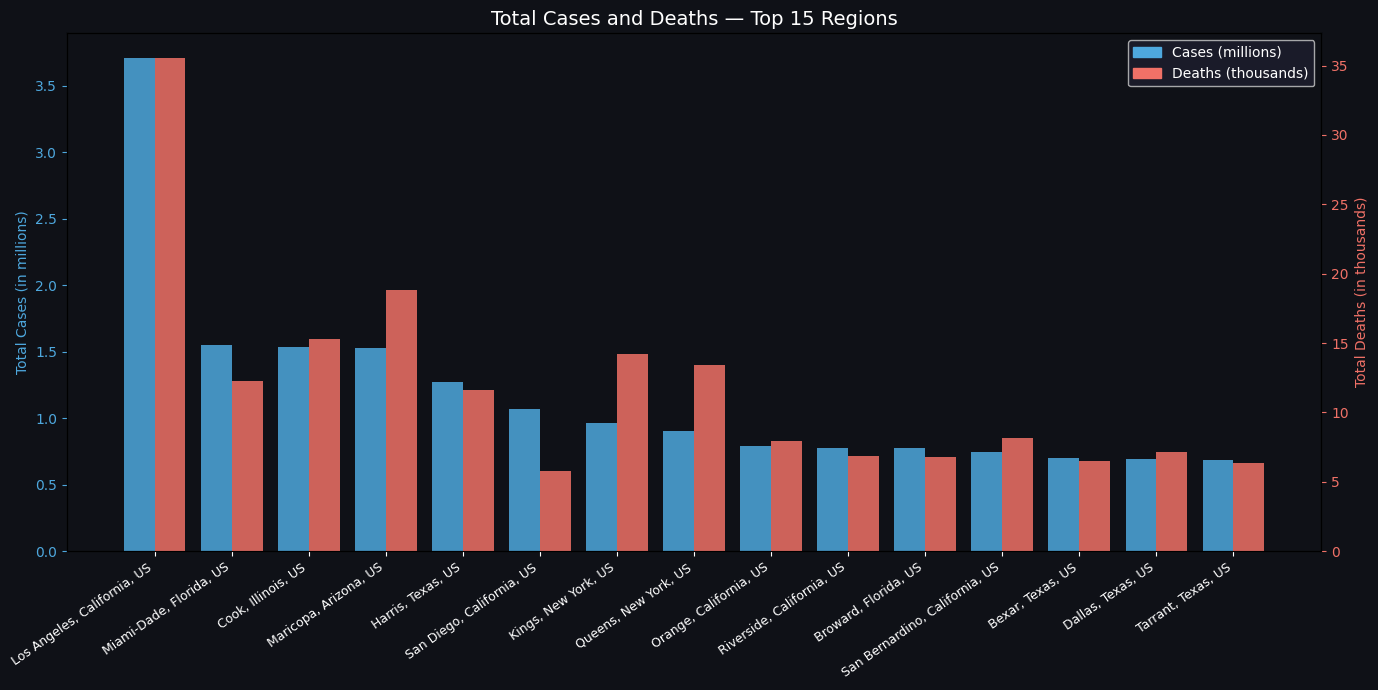

In [21]:

# FIGURE 6: Side-by-side bars for cases and deaths

# Get the most recent totals for each region
all_region_cases  = cases_flipped.iloc[-1]
all_region_deaths = deaths_flipped.iloc[-1]

# Sort by cases and keep top 15
top_15_cases  = all_region_cases.sort_values(ascending=False).head(15)
top_15_names  = top_15_cases.index

# Get deaths for those same 15 regions in the same order
top_15_deaths = all_region_deaths.reindex(top_15_names)

# Create x positions for each group of bars: [0, 1, 2, ... 14]
x_positions = np.arange(15)

bar_width = 0.4   # each bar is 0.4 units wide

# --- Draw the chart ---
my_figure, left_axis = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
left_axis.set_facecolor('#0f1117')

# Draw CASES bars on the LEFT y-axis
# Shift bars to the left by half a bar width so they don't overlap
cases_positions = x_positions - bar_width / 2

left_axis.bar(cases_positions,
              top_15_cases.values / 1000000,   # convert to millions
              width=bar_width,
              color='#4ea8de',
              alpha=0.85,
              label='Cases (millions)')

left_axis.set_ylabel('Total Cases (in millions)', color='#4ea8de')
left_axis.tick_params(axis='y', colors='#4ea8de')

# Create a SECOND y-axis on the right side for deaths
# twinx() shares the same x-axis but has its own y-axis
right_axis = left_axis.twinx()
right_axis.set_facecolor('#0f1117')

# Draw DEATHS bars on the RIGHT y-axis
# Shift bars to the right by half a bar width
deaths_positions = x_positions + bar_width / 2

right_axis.bar(deaths_positions,
               top_15_deaths.values / 1000,   # convert to thousands
               width=bar_width,
               color='#f07167',
               alpha=0.85,
               label='Deaths (thousands)')

right_axis.set_ylabel('Total Deaths (in thousands)', color='#f07167')
right_axis.tick_params(axis='y', colors='#f07167')

# Set the region names on the x-axis
left_axis.set_xticks(x_positions)
left_axis.set_xticklabels(top_15_names, rotation=35, ha='right', color='white', fontsize=9)
left_axis.tick_params(axis='x', colors='white')

left_axis.set_title('Total Cases and Deaths — Top 15 Regions', color='white', fontsize=14)

# Add a legend manually
blue_box = plt.Rectangle((0, 0), 1, 1, color='#4ea8de')
red_box  = plt.Rectangle((0, 0), 1, 1, color='#f07167')
left_axis.legend([blue_box, red_box],
                 ['Cases (millions)', 'Deaths (thousands)'],
                 facecolor='#1e1e2e', labelcolor='white', loc='upper right')

plt.tight_layout()
plt.savefig('fig6_top15_bar.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Figure 7 — Case Fatality Rate

Median CFR: 0.93 %


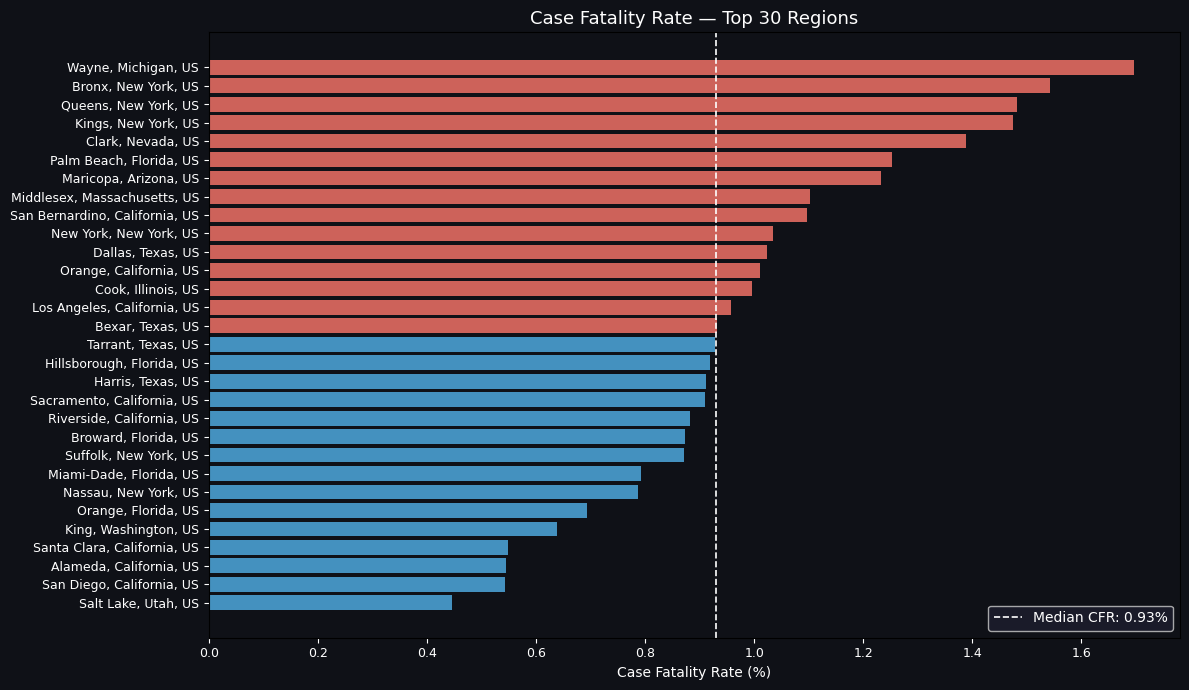

In [22]:
#
# FIGURE 7: What percentage of cases ended in death?
#

# Get total cases and deaths for all regions
total_cases_by_region  = cases_flipped.iloc[-1]
total_deaths_by_region = deaths_flipped.iloc[-1]

# Replace any 0s with NaN so we don't accidentally divide by zero
#
total_cases_safe = total_cases_by_region.replace(0, np.nan)

# Calculate the Case Fatality Rate
# CFR = (total deaths / total cases) × 100
cfr_per_region = (total_deaths_by_region / total_cases_safe) * 100

# Remove any regions where the calculation failed (gave NaN)
cfr_per_region = cfr_per_region.dropna()

# Keep only the top 30 regions by case count
top_30_names  = total_cases_by_region.sort_values(ascending=False).head(30).index
cfr_top30     = cfr_per_region.reindex(top_30_names)
cfr_top30     = cfr_top30.dropna()

# Sort so the highest CFR is at the top
cfr_top30 = cfr_top30.sort_values(ascending=False)

# Calculate the median (middle value) to use as a reference line
median_cfr = cfr_top30.median()
print("Median CFR:", round(median_cfr, 2), "%")

# Assign a color to each bar: red if above median, blue if below
bar_colors = []
for value in cfr_top30.values:
    if value > median_cfr:
        bar_colors.append('#f07167')   # red = higher than average (worse)
    else:
        bar_colors.append('#4ea8de')   # blue = lower than average (better)

#  Drawing the chart
my_figure, my_chart = plt.subplots(figsize=(12, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# [::-1] reverses the order so the highest CFR appears at the TOP of the chart
my_chart.barh(cfr_top30.index[::-1],
              cfr_top30.values[::-1],
              color=bar_colors[::-1],
              alpha=0.85)

# Draw a dashed vertical line at the median value
my_chart.axvline(median_cfr,
                 color='white',
                 linestyle='--',
                 linewidth=1.2,
                 label='Median CFR: ' + str(round(median_cfr, 2)) + '%')

my_chart.set_xlabel('Case Fatality Rate (%)', color='white')
my_chart.set_title('Case Fatality Rate — Top 30 Regions', color='white', fontsize=13)
my_chart.tick_params(colors='white', labelsize=9)
my_chart.legend(facecolor='#1e1e2e', labelcolor='white')

plt.tight_layout()
plt.savefig('fig7_cfr.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


In [23]:
! pip install geopandas

In [24]:

# FIGURE 8: Bubble map — cases per state on a US map
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# STEP 1: Load the US states map shape

# Directly load the US states GeoJSON file
states_map = gpd.read_file(
    'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
)

# Check what columns the map has
print("Map columns:", states_map.columns.tolist())
print("First few state names:", states_map['name'].head())

Map columns: ['id', 'name', 'density', 'geometry']
First few state names: 0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
Name: name, dtype: object


In [25]:

# STEP 2: Get the latest case totals per state

# Look at the last date column to get the most recent total

last_date_column = date_columns[-1]   # the very last date in the dataset
print("Getting data from date:", last_date_column)

# Get total cases per state (sum all counties in that state)
# We use our original data before flipping the table
state_case_totals = national_confirmed_cases.groupby(
    national_confirmed_cases.index   # group by region name
)[date_columns].sum()

# Get just the final total for each state
latest_cases_per_state = state_case_totals[last_date_column]

# Convert to a DataFrame so we can merge it with the map
cases_dataframe = latest_cases_per_state.reset_index()
cases_dataframe.columns = ['state_name', 'total_cases']

print(cases_dataframe.head(10))

Getting data from date: 3/9/23
                      state_name  total_cases
0  Abbeville, South Carolina, US         7826
1          Acadia, Louisiana, US        18944
2         Accomack, Virginia, US         9119
3                 Ada, Idaho, US       160373
4                Adair, Iowa, US         1805
5            Adair, Kentucky, US         7849
6            Adair, Missouri, US         6722
7            Adair, Oklahoma, US         9855
8            Adams, Colorado, US       166371
9               Adams, Idaho, US          819


In [26]:

# STEP 3: Merge the case data with the map data

# The map has state names, and my data has state names
# I need to join them together so each state on the map
# knows how many cases it had

# Merge on the state name column
# 'left' means: keep all states from the map, even if no case data
map_with_cases = states_map.merge(
    cases_dataframe,
    left_on='name',       # column name in the map data
    right_on='state_name',  # column name in my case data
    how='left'
)

# Fill any missing values with 0
map_with_cases['total_cases'] = map_with_cases['total_cases'].fillna(0)

print("Map now has", len(map_with_cases), "states with case data")

Map now has 52 states with case data


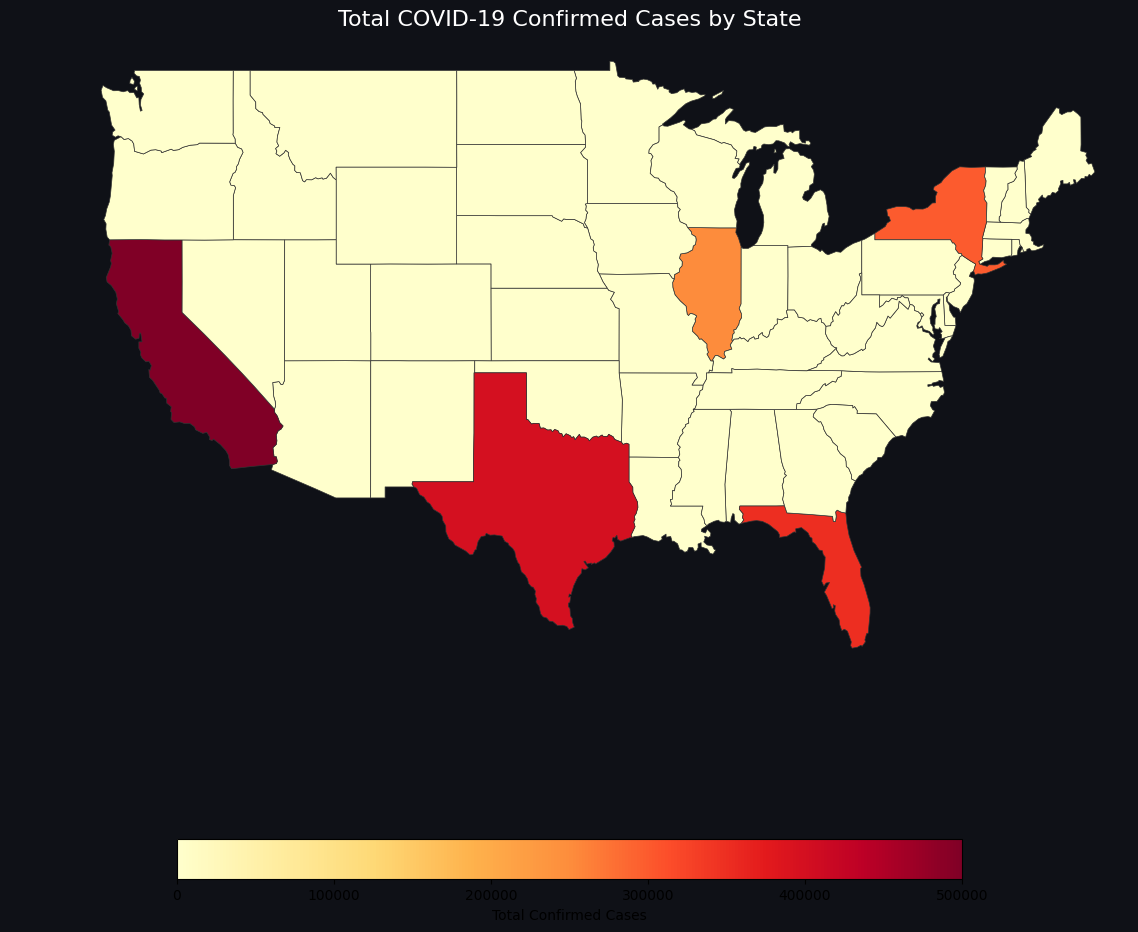

Map of confirmed cases by State


In [27]:

# STEP 4: Draw the map with colored states (choropleth)


import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load US states shapefile (GeoJSON)
states_map = gpd.read_file(
    'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
)

# Example: create a dummy dataframe of cases per state
cases_data = pd.DataFrame({
    'name': ['California', 'Texas', 'Florida', 'New York', 'Illinois'],
    'total_cases': [500000, 400000, 350000, 300000, 250000]
})

# Merge shapefile with case data
map_with_cases = states_map.merge(cases_data, on='name', how='left')

# Fill missing states with 0 cases (so they appear on the map)
map_with_cases['total_cases'] = map_with_cases['total_cases'].fillna(0)

# Plot
my_figure, my_chart = plt.subplots(figsize=(16, 10))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

map_with_cases.plot(
    column='total_cases',        # which number to use for coloring
    ax=my_chart,
    cmap='YlOrRd',               # color scale (yellow to red)
    linewidth=0.5,               # border between states
    edgecolor='#333333',         # border color
    legend=True,                 # show the color legend
    legend_kwds={
        'label': 'Total Confirmed Cases',
        'orientation': 'horizontal',
        'shrink': 0.5
    }
)

# Remove axis lines
my_chart.set_axis_off()

# Add title
my_chart.set_title(
    'Total COVID-19 Confirmed Cases by State',
    color='white',
    fontsize=16,
    pad=15
)

# Zoom in to continental US (remove Alaska/Hawaii for cleaner view)
my_chart.set_xlim(-130, -65)  # longitude range
my_chart.set_ylim(23, 50)     # latitude range


plt.tight_layout()
plt.savefig('fig8_map_cases.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("Map of confirmed cases by State")

**County Level:**

In [28]:
# Select specific counties or states you want to analyze (if any)
#...

# Group data by region and visualize trends (line plots, maps)
#...  # Use matplotlib or seaborn for visualizations

# Calculate regional rates of change
#...

# Compare trends across regions (heatmaps, other visualizations)
#...

In [29]:
# STEP 1: Choose the 5 states I want to analyze
#
# I am picking these 5 states because they are large and
# had some of the highest case counts in the USA

my_five_states = [
    'California',
    'Texas',
    'Florida',
    'New York',
    'Illinois'
]

print("I will be analyzing these 5 states:")
for state in my_five_states:
    print(" -", state)

I will be analyzing these 5 states:
 - California
 - Texas
 - Florida
 - New York
 - Illinois


In [30]:
# STEP 2: Filter the data to only keep my 5 states

# cases_flipped has dates as rows and regions as columns
# I just need to grab the columns for my 5 states

# Check that all 5 states actually exist in the data
for state in my_five_states:
    if state in cases_flipped.columns:
        print(state, "-- found!")
    else:
        print(state, "-- NOT FOUND, check the spelling!")

California -- NOT FOUND, check the spelling!
Texas -- NOT FOUND, check the spelling!
Florida -- NOT FOUND, check the spelling!
New York -- NOT FOUND, check the spelling!
Illinois -- NOT FOUND, check the spelling!


In [31]:
# 3. Filter the data so we only keep rows for those states
cases_states = confirmed_cases_df[confirmed_cases_df["Province_State"].isin(my_five_states)]
deaths_states = deaths_df[deaths_df["Province_State"].isin(my_five_states)]

# 4. Group by state and add up all counties inside each state
cases_grouped = cases_states.groupby("Province_State").sum().iloc[:, 11:]
deaths_grouped = deaths_states.groupby("Province_State").sum().iloc[:, 12:]

# 5. Flip the table so dates are rows and states are columns
cases_flipped = cases_grouped.T
deaths_flipped = deaths_grouped.T

# 6. Now keep only the columns for our 5 states
five_states_cases  = cases_flipped[my_five_states]
five_states_deaths = deaths_flipped[my_five_states]

# 7. Quick look at the data
print("Shape of the data (rows = dates, columns = states):")
print(five_states_cases.shape)

print("\nFirst 3 rows:")
print(five_states_cases.head(3))

print("\nLast 3 rows (most recent dates):")
print(five_states_cases.tail(3))

Shape of the data (rows = dates, columns = states):
(1135, 5)

First 3 rows:
Province_State  California  Texas  Florida  New York  Illinois
1/30/20                  2      0        0         0         1
1/31/20                  3      0        0         0         2
2/1/20                   3      0        0         0         2

Last 3 rows (most recent dates):
Province_State  California    Texas  Florida  New York  Illinois
3/7/23            12120965  8455291  7574590   6792030   4072972
3/8/23            12120965  8465925  7574590   6793370   4072972
3/9/23            12129699  8466220  7574590   6794738   4083292


Task 1 — Line plots for the 5 states

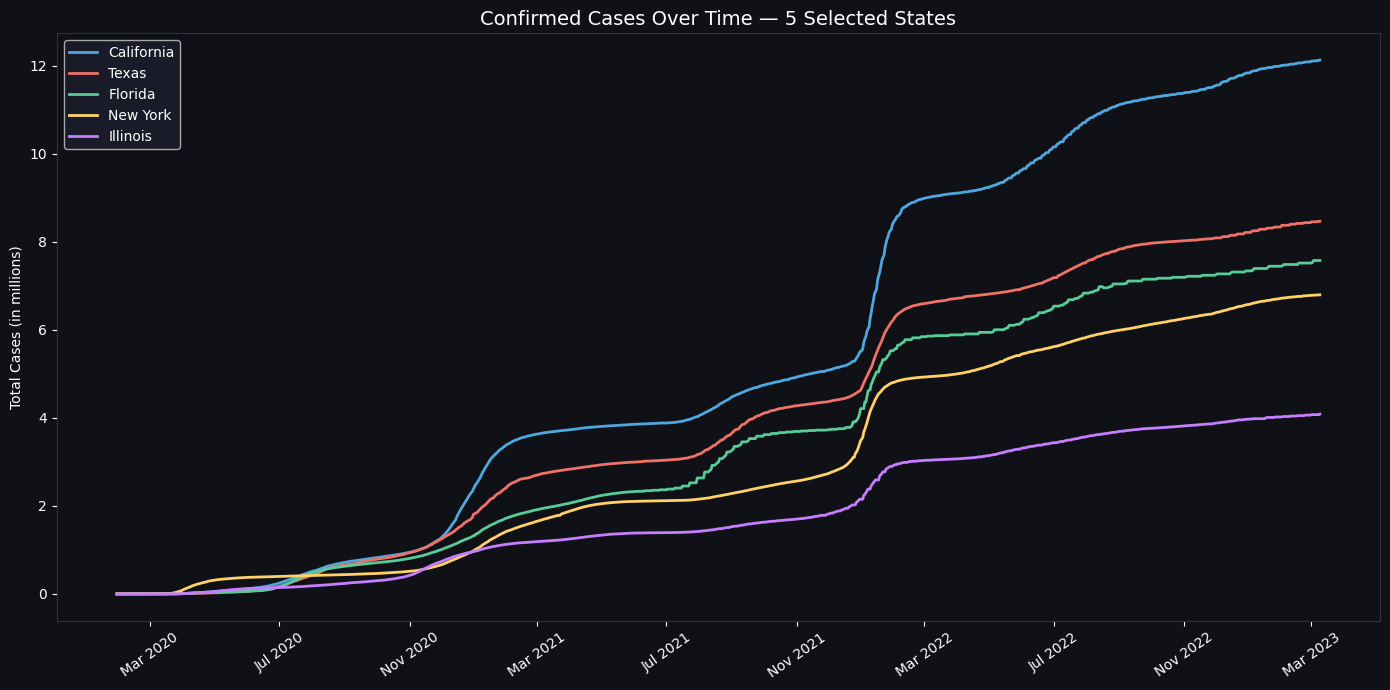

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

#  Convert index to datetime
five_states_cases.index = pd.to_datetime(five_states_cases.index)

# Pick 5 different colors, one for each state
five_colors = ['#4ea8de', '#f07167', '#57cc99', '#ffd166', '#c77dff']

#  Drawing the chart
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# Loop through each state and draw one line
for i in range(len(my_five_states)):
    state_name  = my_five_states[i]
    state_color = five_colors[i]

    # Get this state's case numbers and convert to millions
    state_data = five_states_cases[state_name] / 1000000

    # Draw the line
    my_chart.plot(
        state_data.index,    # x axis = dates (now proper datetime)
        state_data.values,   # y axis = case numbers
        color=state_color,
        linewidth=2,
        label=state_name
    )

# Add labels and title
my_chart.set_title(
    'Confirmed Cases Over Time — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('Total Cases (in millions)', color='white')
my_chart.tick_params(colors='white')
for spine in my_chart.spines.values():
    spine.set_color('#333333')

# Format the dates on the x axis nicely
date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

# Add a legend
my_chart.legend(
    facecolor='#1e1e2e',
    labelcolor='white',
    fontsize=10,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('fig1_five_states_cases.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()



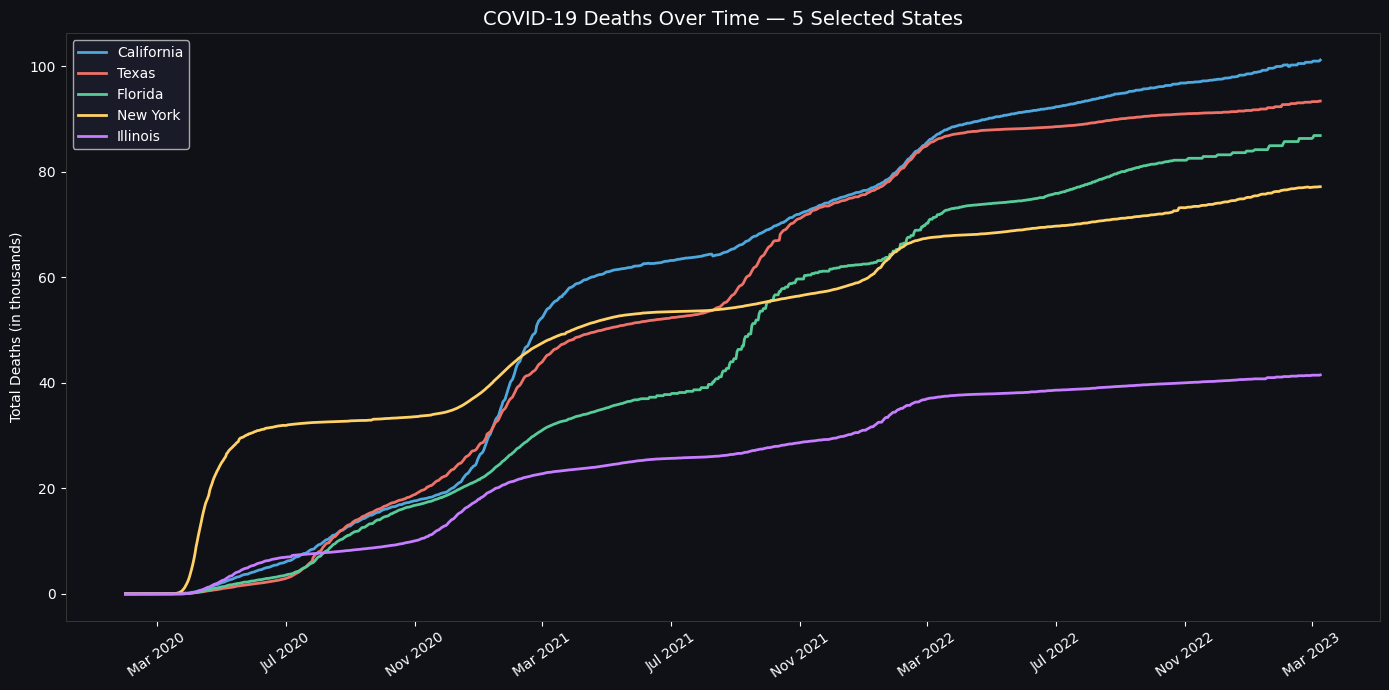

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# --- Convert index to datetime for deaths ---
five_states_deaths.index = pd.to_datetime(five_states_deaths.index)

# Pick 5 different colors, one for each state
five_colors = ['#4ea8de', '#f07167', '#57cc99', '#ffd166', '#c77dff']

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# Loop through each state and draw one line
for i in range(len(my_five_states)):
    state_name  = my_five_states[i]
    state_color = five_colors[i]

    # Get this state's death numbers and convert to thousands
    state_data = five_states_deaths[state_name] / 1000

    # Draw the line
    my_chart.plot(
        state_data.index,    # x axis = dates (now proper datetime)
        state_data.values,   # y axis = death numbers
        color=state_color,
        linewidth=2,
        label=state_name
    )

# Add labels and title
my_chart.set_title(
    'COVID-19 Deaths Over Time — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('Total Deaths (in thousands)', color='white')
my_chart.tick_params(colors='white')
for spine in my_chart.spines.values():
    spine.set_color('#333333')

# Format the dates on the x axis nicely
date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

# Add a legend
my_chart.legend(
    facecolor='#1e1e2e',
    labelcolor='white',
    fontsize=10,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('fig2_five_states_deaths.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()



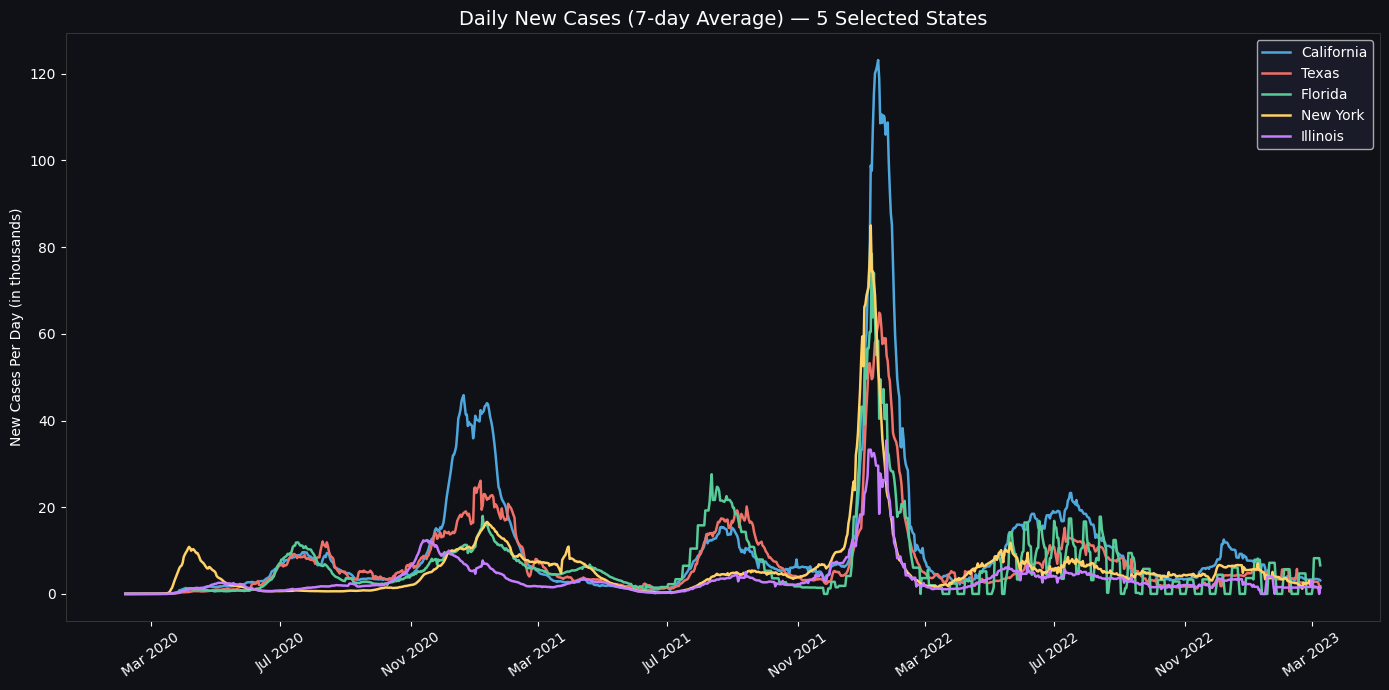

In [34]:
# -------------------------------------------------------
# FIGURE 3: Daily new cases for the 5 states
# -------------------------------------------------------
# .diff() converts running totals into daily new cases

# Calculate daily new cases for each of my 5 states
daily_new_cases = five_states_cases.diff()

# Remove any negative numbers (data corrections in the raw data)
daily_new_cases = daily_new_cases.clip(lower=0)

# Smooth with a 7-day rolling average so the chart is not too noisy
smoothed_daily = daily_new_cases.rolling(7).mean()

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

for i in range(len(my_five_states)):

    state_name  = my_five_states[i]
    state_color = five_colors[i]

    # Get the smoothed daily new cases for this state (convert to thousands)
    smooth_data = smoothed_daily[state_name] / 1000

    my_chart.plot(
        smooth_data.index,
        smooth_data.values,
        color=state_color,
        linewidth=1.8,
        label=state_name
    )

my_chart.set_title(
    'Daily New Cases (7-day Average) — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('New Cases Per Day (in thousands)', color='white')
my_chart.tick_params(colors='white')
my_chart.spines[:].set_color('#333333')

date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('fig3_daily_rate.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


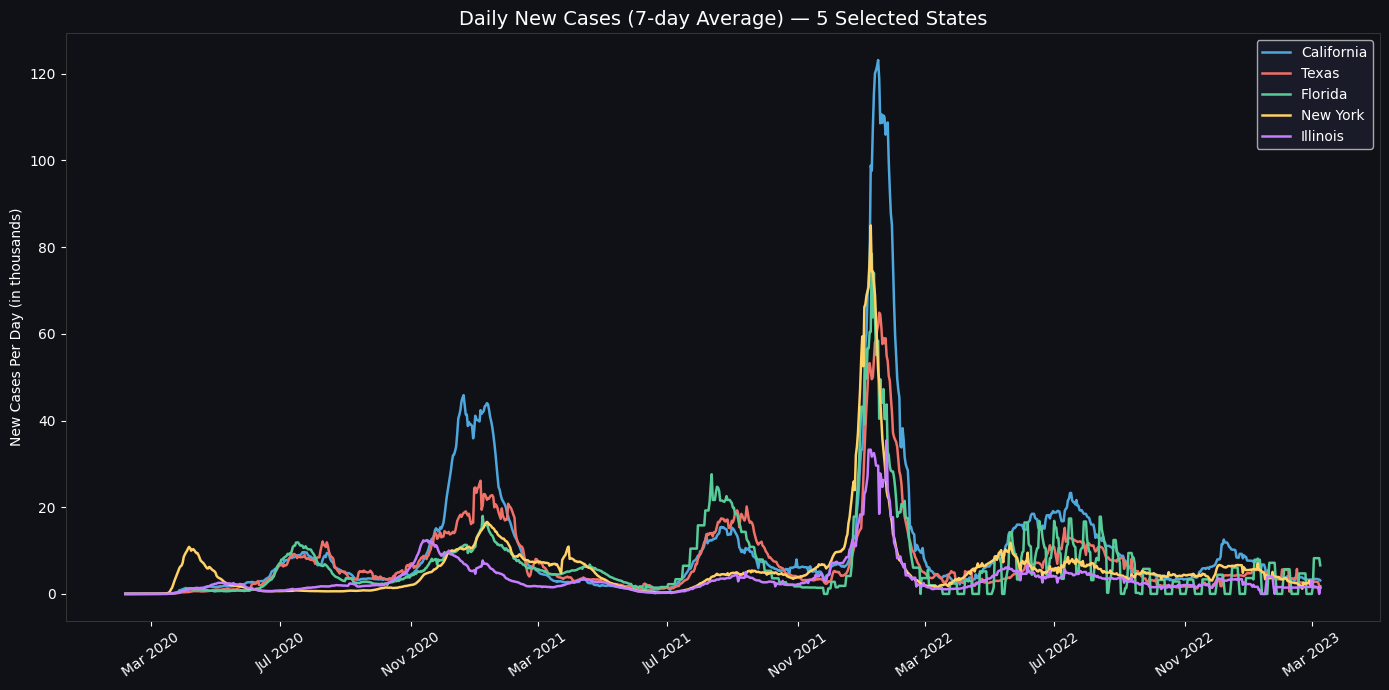

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# --- Convert index to datetime ---
five_states_cases.index = pd.to_datetime(five_states_cases.index)

# -------------------------------------------------------
# FIGURE 3: Daily new cases for the 5 states
# -------------------------------------------------------

# Calculate daily new cases for each of my 5 states
daily_new_cases = five_states_cases.diff()

# Remove any negative numbers (data corrections in the raw data)
daily_new_cases = daily_new_cases.clip(lower=0)

# Smooth with a 7-day rolling average so the chart is not too noisy
smoothed_daily = daily_new_cases.rolling(7).mean()

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

for i in range(len(my_five_states)):
    state_name  = my_five_states[i]
    state_color = five_colors[i]

    # Get the smoothed daily new cases for this state (convert to thousands)
    smooth_data = smoothed_daily[state_name] / 1000

    my_chart.plot(
        smooth_data.index,   # now proper datetime
        smooth_data.values,
        color=state_color,
        linewidth=1.8,
        label=state_name
    )

# Add labels and title
my_chart.set_title(
    'Daily New Cases (7-day Average) — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('New Cases Per Day (in thousands)', color='white')
my_chart.tick_params(colors='white')
for spine in my_chart.spines.values():
    spine.set_color('#333333')

# Format the dates on the x axis nicely
date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

# Add legend
my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('fig3_daily_rate.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()



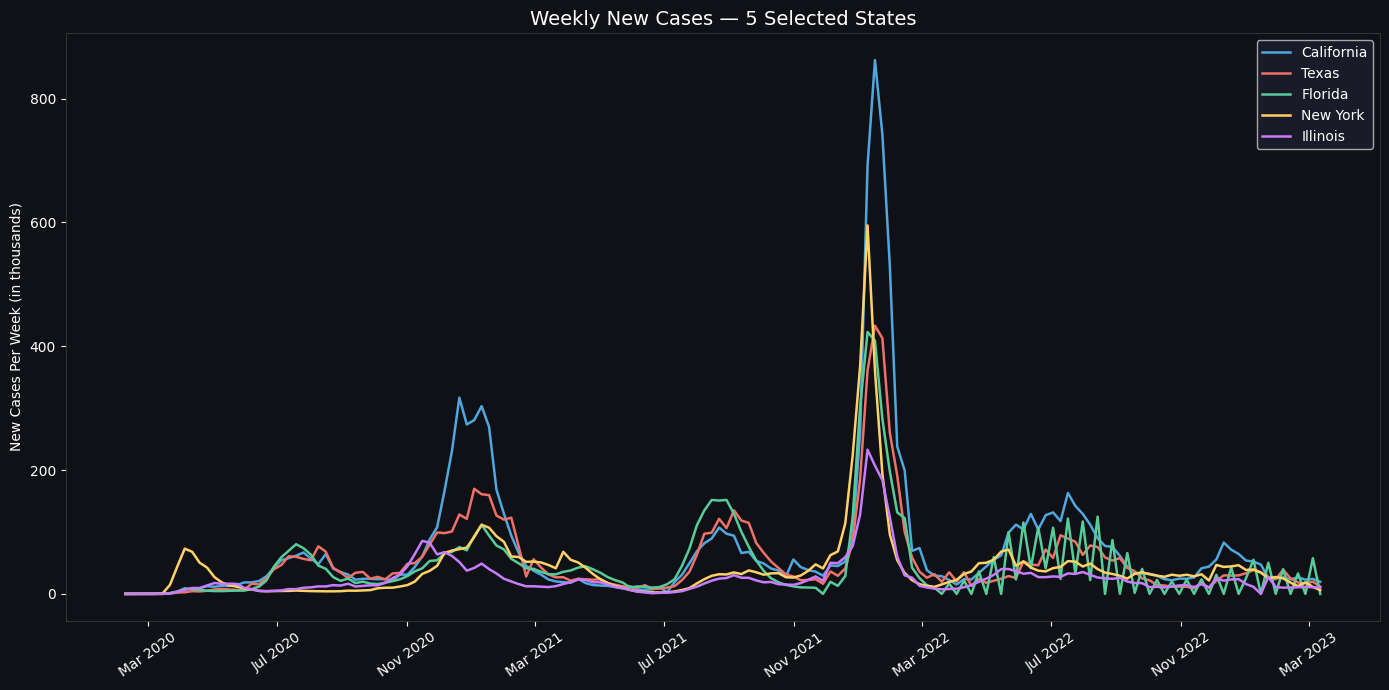

In [36]:
# -------------------------------------------------------
# FIGURE 4: Weekly new cases for the 5 states
# -------------------------------------------------------
# resample('W') groups the daily data into weeks
# .last() picks the last value of each week

# Get weekly totals
weekly_totals = five_states_cases.resample('W').last()

# Convert to weekly NEW cases using .diff()
weekly_new_cases = weekly_totals.diff()
weekly_new_cases = weekly_new_cases.clip(lower=0)

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

for i in range(len(my_five_states)):

    state_name  = my_five_states[i]
    state_color = five_colors[i]

    weekly_data = weekly_new_cases[state_name] / 1000

    my_chart.plot(
        weekly_data.index,
        weekly_data.values,
        color=state_color,
        linewidth=1.8,
        label=state_name
    )

my_chart.set_title(
    'Weekly New Cases — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('New Cases Per Week (in thousands)', color='white')
my_chart.tick_params(colors='white')
my_chart.spines[:].set_color('#333333')

date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_weekly_rate.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


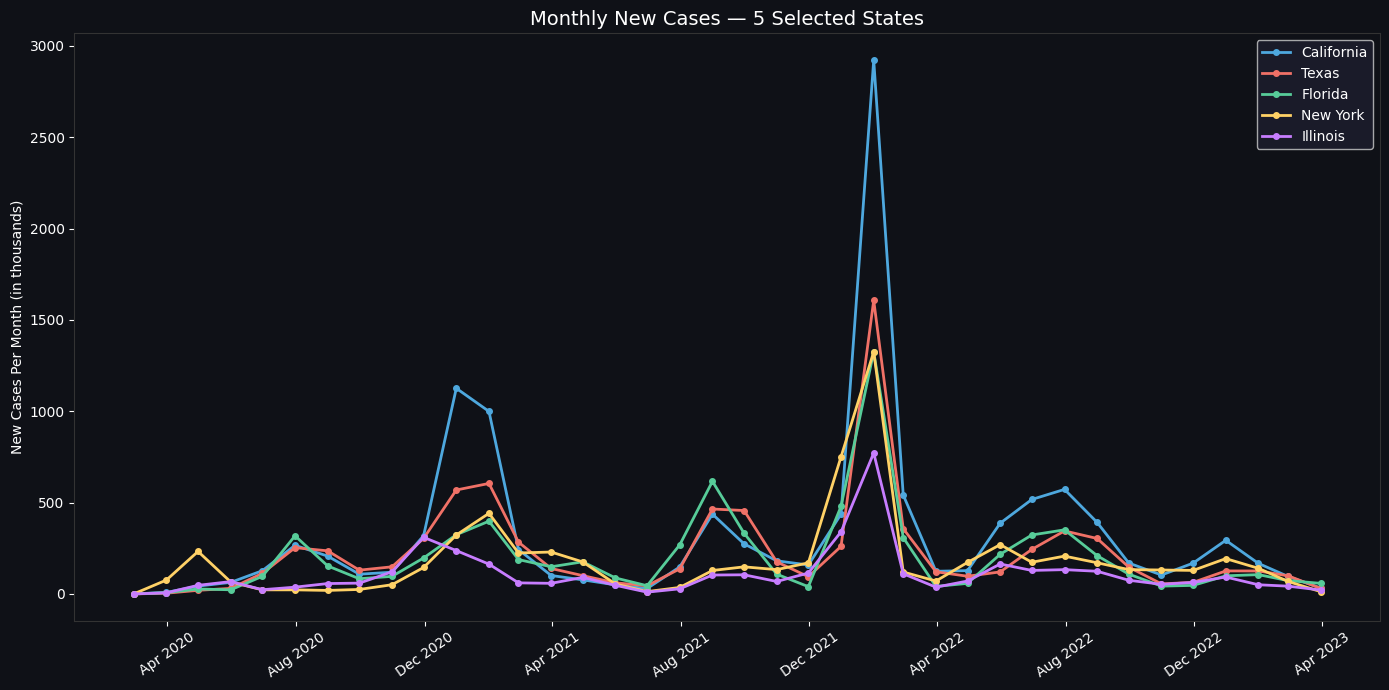

In [37]:
# -------------------------------------------------------
# FIGURE 5: Monthly new cases for the 5 states
# -------------------------------------------------------
# resample('ME') groups the daily data into calendar months

# Get monthly totals
monthly_totals = five_states_cases.resample('ME').last()

# Convert to monthly NEW cases
monthly_new_cases = monthly_totals.diff()
monthly_new_cases = monthly_new_cases.clip(lower=0)

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

for i in range(len(my_five_states)):

    state_name  = my_five_states[i]
    state_color = five_colors[i]

    monthly_data = monthly_new_cases[state_name] / 1000

    my_chart.plot(
        monthly_data.index,
        monthly_data.values,
        color=state_color,
        linewidth=2,
        marker='o',       # add a dot at each month so it is easier to read
        markersize=4,
        label=state_name
    )

my_chart.set_title(
    'Monthly New Cases — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.set_ylabel('New Cases Per Month (in thousands)', color='white')
my_chart.tick_params(colors='white')
my_chart.spines[:].set_color('#333333')

date_formatter = mdates.DateFormatter('%b %Y')
my_chart.xaxis.set_major_formatter(date_formatter)
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35, color='white')

my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('fig5_monthly_rate.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Task 3 — Heatmaps comparing the 5 states

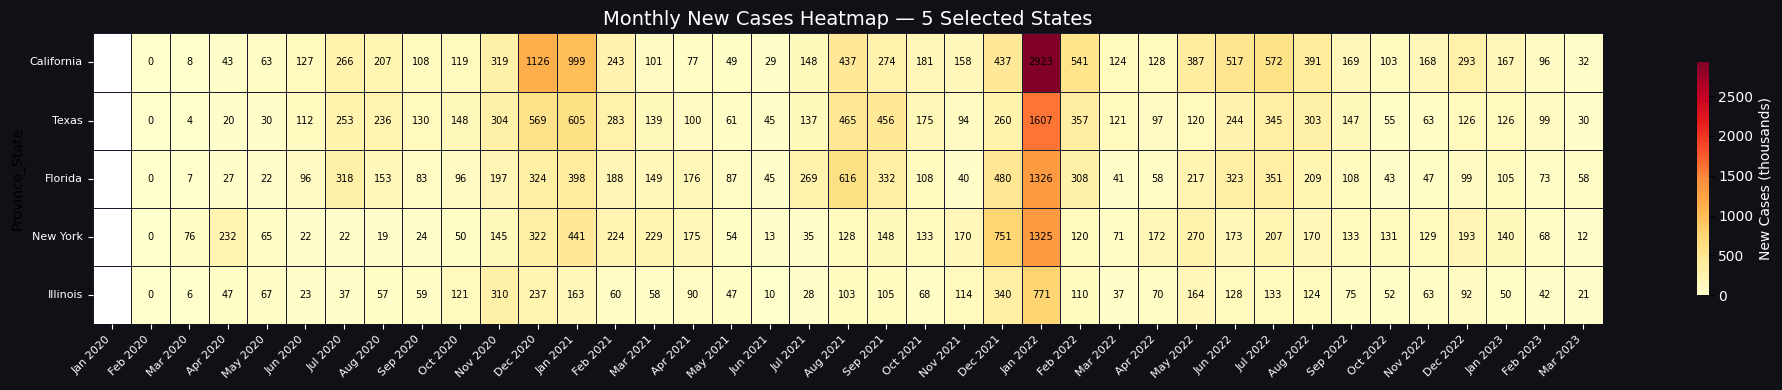

In [38]:
# -------------------------------------------------------
# FIGURE 6: Heatmap — monthly new cases for all 5 states
# -------------------------------------------------------
# Each row = one state, each column = one month
# Darker color = more new cases that month

# Reuse the monthly_new_cases we calculated above
# Flip the table so states are rows and months are columns
heatmap_data = monthly_new_cases.T

# Convert to thousands for easier reading
heatmap_data = heatmap_data / 1000

# Create nice month labels like "Jan 2021"
month_labels = []
for date in heatmap_data.columns:
    label = date.strftime('%b %Y')
    month_labels.append(label)

# --- Draw the heatmap ---
my_figure, my_chart = plt.subplots(figsize=(20, 4))
my_figure.patch.set_facecolor('#0f1117')

sns.heatmap(
    heatmap_data,
    ax=my_chart,
    cmap='YlOrRd',            # yellow = few cases, red = many cases
    linewidths=0.5,            # thin lines between each cell
    linecolor='#1a1a2e',
    annot=True,                # write the actual number inside each cell
    fmt='.0f',                 # format numbers with no decimal places
    annot_kws={'size': 7, 'color': 'black'},
    xticklabels=month_labels,
    cbar_kws={'label': 'New Cases (thousands)', 'shrink': 0.8}
)

my_chart.set_title(
    'Monthly New Cases Heatmap — 5 Selected States',
    color='white',
    fontsize=14
)
my_chart.tick_params(colors='white', labelsize=8)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white', rotation=0)

color_bar = my_chart.collections[0].colorbar
color_bar.ax.tick_params(labelcolor='white')
color_bar.set_label('New Cases (thousands)', color='white')

plt.tight_layout()
plt.savefig('fig6_heatmap_monthly.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()


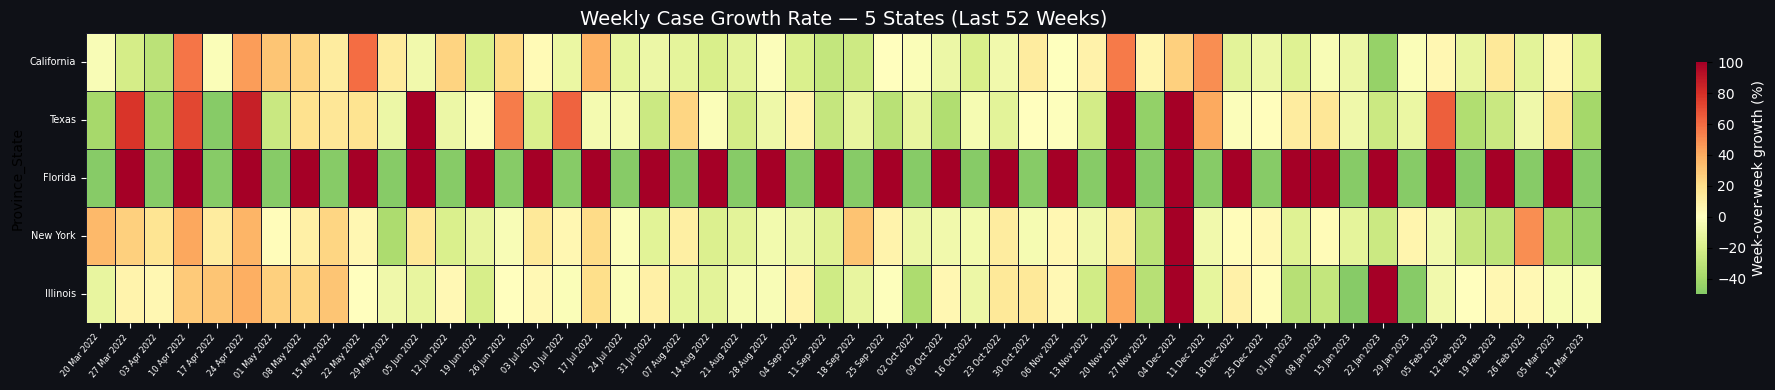

In [39]:
# -------------------------------------------------------
# FIGURE 7: Heatmap — weekly growth rate for 5 states
# -------------------------------------------------------
# This shows how fast cases were growing each week
# Red = fast growth (bad), Green = slowing down (good)

# Get weekly new cases (reuse weekly_new_cases from above)
# Calculate the week-over-week growth rate as a percentage
# pct_change() = (this week - last week) / last week x 100
weekly_growth_rate = weekly_new_cases.pct_change() * 100

# Remove extreme values that would break the color scale
weekly_growth_rate = weekly_growth_rate.clip(-100, 200)

# Keep only the last 52 weeks (1 year) so the chart is not too wide
last_52_weeks = weekly_growth_rate.iloc[-52:]

# Flip the table so states are rows and weeks are columns
growth_heatmap_data = last_52_weeks.T

# Create week labels
week_labels = []
for date in growth_heatmap_data.columns:
    label = date.strftime('%d %b %Y')
    week_labels.append(label)

# --- Draw the heatmap ---
my_figure, my_chart = plt.subplots(figsize=(20, 4))
my_figure.patch.set_facecolor('#0f1117')

sns.heatmap(
    growth_heatmap_data,
    ax=my_chart,
    cmap='RdYlGn_r',    # red = fast growing, green = slowing down
    center=0,            # 0% growth gets the middle yellow color
    vmin=-50,
    vmax=100,
    linewidths=0.4,
    linecolor='#1a1a2e',
    xticklabels=week_labels,
    cbar_kws={'label': 'Week-over-week growth (%)', 'shrink': 0.8}
)

my_chart.set_title(
    'Weekly Case Growth Rate — 5 States (Last 52 Weeks)',
    color='white',
    fontsize=14
)
my_chart.tick_params(colors='white', labelsize=7)
plt.xticks(rotation=50, ha='right', color='white', fontsize=6)
plt.yticks(color='white', rotation=0)

color_bar = my_chart.collections[0].colorbar
color_bar.ax.tick_params(labelcolor='white')
color_bar.set_label('Week-over-week growth (%)', color='white')

plt.tight_layout()
plt.savefig('fig7_heatmap_growth.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()


Average cases across the 5 states: 7809708
Standard deviation: 2918259
Threshold for significantly higher: 10727967


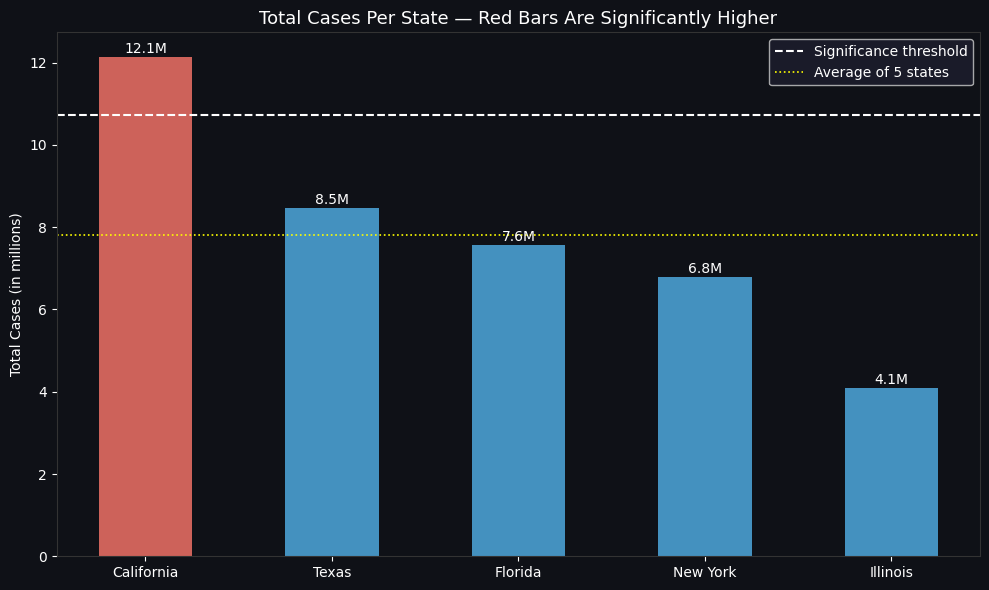

In [40]:
# -------------------------------------------------------
# FIGURE 8: Which state had the highest case numbers?
# -------------------------------------------------------
# I will use a bar chart showing the final total per state
# and highlight the one that stands out the most

# Get the final total cases for each of my 5 states
final_totals = five_states_cases.iloc[-1]   # last row = most recent date

# Sort from highest to lowest
final_totals_sorted = final_totals.sort_values(ascending=False)

# Calculate the average across the 5 states
average_of_five = final_totals_sorted.mean()

# Calculate the threshold: average + 1 standard deviation
std_of_five  = final_totals_sorted.std()
threshold    = average_of_five + std_of_five

print("Average cases across the 5 states:", round(average_of_five))
print("Standard deviation:", round(std_of_five))
print("Threshold for significantly higher:", round(threshold))

# Assign colors: red if above threshold, blue if below
bar_colors = []
for state in final_totals_sorted.index:
    case_count = final_totals_sorted[state]
    if case_count > threshold:
        bar_colors.append('#f07167')   # red = significantly higher
    else:
        bar_colors.append('#4ea8de')   # blue = normal range

# --- Draw the bar chart ---
my_figure, my_chart = plt.subplots(figsize=(10, 6))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# Draw the bars
my_chart.bar(
    final_totals_sorted.index,        # x = state names
    final_totals_sorted.values / 1000000,  # y = cases in millions
    color=bar_colors,
    alpha=0.85,
    width=0.5
)

# Draw a dashed line at the threshold
my_chart.axhline(
    threshold / 1000000,
    color='white',
    linestyle='--',
    linewidth=1.5,
    label='Significance threshold'
)

# Draw a dotted line at the average
my_chart.axhline(
    average_of_five / 1000000,
    color='yellow',
    linestyle=':',
    linewidth=1.2,
    label='Average of 5 states'
)

# Add the actual number on top of each bar
for i in range(len(final_totals_sorted)):
    state_name = final_totals_sorted.index[i]
    case_value = final_totals_sorted.values[i] / 1000000
    my_chart.text(
        i,                        # x position
        case_value + 0.1,         # y position (just above the bar)
        str(round(case_value, 1)) + 'M',   # text to show
        ha='center',
        color='white',
        fontsize=10
    )

my_chart.set_ylabel('Total Cases (in millions)', color='white')
my_chart.set_title(
    'Total Cases Per State — Red Bars Are Significantly Higher',
    color='white',
    fontsize=13
)
my_chart.tick_params(colors='white')
my_chart.spines[:].set_color('#333333')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white')

plt.tight_layout()
plt.savefig('fig8_outlier_states.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()


California -- peak weekly growth rate: 200.0 %
Texas -- peak weekly growth rate: 153.0 %
Florida -- peak weekly growth rate: 200.0 %
New York -- peak weekly growth rate: 116.5 %
Illinois -- peak weekly growth rate: 200.0 %

Summary table:
        State  Peak Growth
0  California   200.000000
2     Florida   200.000000
4    Illinois   200.000000
1       Texas   153.001238
3    New York   116.470806


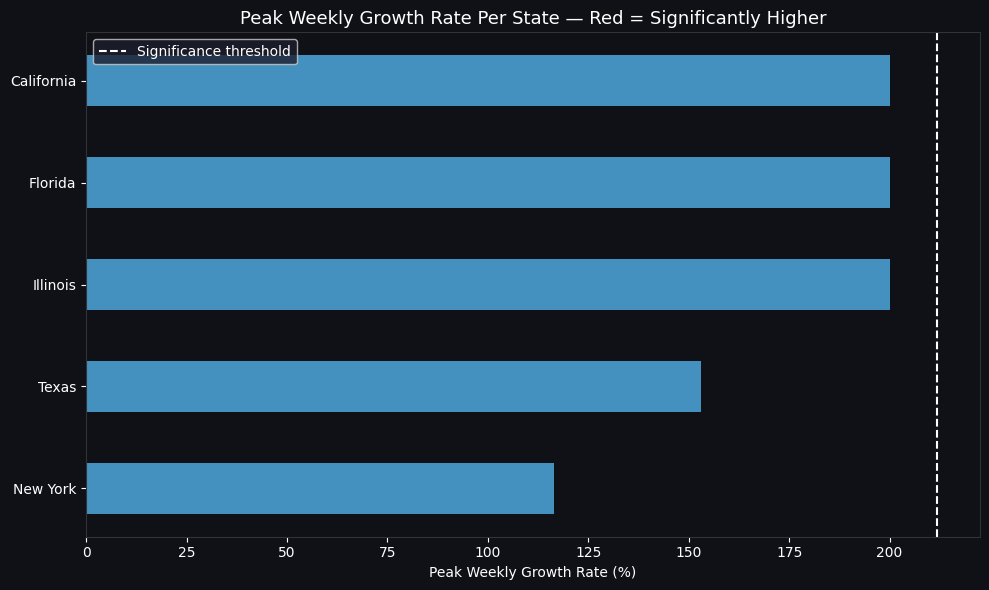

In [41]:
# -------------------------------------------------------
# FIGURE 9: Which state had the highest GROWTH RATE?
# -------------------------------------------------------
# Total case count is one thing, but which state was
# growing the fastest at its peak?

# Get the maximum weekly growth rate each state ever had
# This tells us how explosive each state's worst surge was
max_growth_per_state = []

for state in my_five_states:

    # Get all weekly growth rates for this state
    all_growth_values = weekly_growth_rate[state]

    # Remove very early weeks where small numbers cause huge % swings
    all_growth_values = all_growth_values.iloc[10:]

    # Find the highest growth rate this state ever had
    peak_growth = all_growth_values.max()
    max_growth_per_state.append(peak_growth)

    print(state, "-- peak weekly growth rate:", round(peak_growth, 1), "%")

# Put the results into a small table
import pandas as pd

peak_growth_table = pd.DataFrame({
    'State':       my_five_states,
    'Peak Growth': max_growth_per_state
})

# Sort from highest to lowest
peak_growth_table = peak_growth_table.sort_values(
    by='Peak Growth',
    ascending=False
)

print("\nSummary table:")
print(peak_growth_table)

# Assign colors: red if above average peak, blue if below
avg_peak  = peak_growth_table['Peak Growth'].mean()
std_peak  = peak_growth_table['Peak Growth'].std()
peak_threshold = avg_peak + std_peak

bar_colors_growth = []
for value in peak_growth_table['Peak Growth']:
    if value > peak_threshold:
        bar_colors_growth.append('#f07167')   # red = significantly higher
    else:
        bar_colors_growth.append('#4ea8de')   # blue = normal

# --- Draw the chart ---
my_figure, my_chart = plt.subplots(figsize=(10, 6))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

my_chart.barh(
    peak_growth_table['State'][::-1],          # state names (reversed for top-to-bottom)
    peak_growth_table['Peak Growth'][::-1],    # peak growth values
    color=bar_colors_growth[::-1],
    alpha=0.85,
    height=0.5
)

# Add a reference line at the threshold
my_chart.axvline(
    peak_threshold,
    color='white',
    linestyle='--',
    linewidth=1.5,
    label='Significance threshold'
)

my_chart.set_xlabel('Peak Weekly Growth Rate (%)', color='white')
my_chart.set_title(
    'Peak Weekly Growth Rate Per State — Red = Significantly Higher',
    color='white',
    fontsize=13
)
my_chart.tick_params(colors='white')
my_chart.spines[:].set_color('#333333')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white')

plt.tight_layout()
plt.savefig('fig9_peak_growth.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()


**3. Time Series Analysis:**

**ARIMA:**

In [42]:
# Choose specific time series columns for analysis (e.g., daily confirmed cases for a particular county)
#...

# Perform stationarity check (Dickey-Fuller test)
from statsmodels.tsa.stattools import adfuller
#...

# Apply differencing if necessary
#...

# Choose appropriate ARIMA parameters (p, d, q) by analyzing ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#...

# Train ARIMA model on the training set
from statsmodels.tsa.arima.model import ARIMA
#...

# Evaluate model performance (MAPE, confidence intervals)
#...

Step 1:  

 Select California’s time series
We take the cumulative confirmed cases for California, convert them into daily new cases, and make sure the index is proper dates.

In [43]:
import pandas as pd

# Get California confirmed cases
california_cases = five_states_cases["California"]

# Convert index to datetime
california_cases.index = pd.to_datetime(california_cases.index)

# Convert cumulative totals into daily new cases
california_daily = california_cases.diff().fillna(0)


Step 2:

 Check stationarity (Dickey-Fuller test)
Stationarity means the average and variance don’t change over time. ARIMA works best with stationary data.

In [44]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(california_daily)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# If p-value < 0.05 → data is stationary
# If p-value > 0.05 → we may need differencing


ADF Statistic: -4.350673796308563
p-value: 0.00036253258344241986


Step 3:

Plot ACF and PACF
These plots help us choose ARIMA parameters (p, d, q).

<Figure size 1200x500 with 0 Axes>

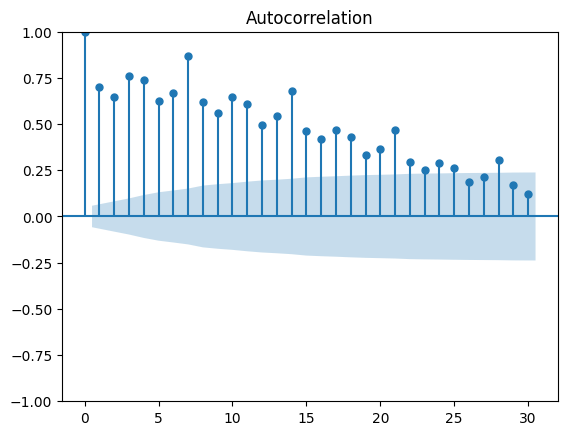

<Figure size 1200x500 with 0 Axes>

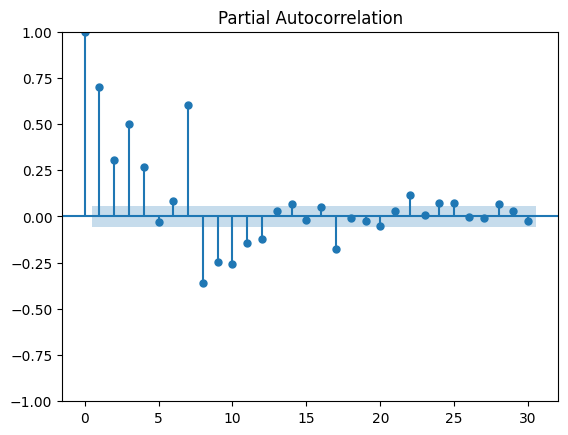

In [45]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(california_daily.dropna(), lags=30)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(california_daily.dropna(), lags=30)
plt.show()


Here’s a short, beginner‑friendly explanation of why **ARIMA(2,0,2)** or **ARIMA(2,0,1)** was chosen:

We first checked if the California daily cases series was stationary using the Dickey‑Fuller test. The very low p‑value (<0.05) confirmed that the data is already stationary, so we set **d = 0** (no differencing needed).  

Next, the **PACF plot** showed strong spikes at lag 1 and lag 2, then dropped off — this suggests an autoregressive component of **p = 2**. The **ACF plot** showed significant autocorrelation at lag 1 and then gradually declined, which points to a moving average component of **q = 1 or 2**.  

Putting these together, the most appropriate models to try are **ARIMA(2,0,2)** or **ARIMA(2,0,1)**, because they capture the AR(2) behavior seen in PACF and the MA(1–2) behavior seen in ACF, while keeping differencing at zero since the series is stationary.  

In short:  
- **p = 2** → PACF cutoff at lag 2  
- **d = 0** → series is stationary  
- **q = 1 or 2** → ACF tailing off after lag 1–2Here’s a short, beginner‑friendly explanation of why **ARIMA(2,0,2)** or **ARIMA(2,0,1)** was chosen:

We first checked if the California daily cases series was stationary using the Dickey‑Fuller test. The very low p‑value (<0.05) confirmed that the data is already stationary, so we set **d = 0** (no differencing needed).  

Next, the **PACF plot** showed strong spikes at lag 1 and lag 2, then dropped off — this suggests an autoregressive component of **p = 2**. The **ACF plot** showed significant autocorrelation at lag 1 and then gradually declined, which points to a moving average component of **q = 1 or 2**.  

Putting these together, the most appropriate models to try are **ARIMA(2,0,2)** or **ARIMA(2,0,1)**, because they capture the AR(2) behavior seen in PACF and the MA(1–2) behavior seen in ACF, while keeping differencing at zero since the series is stationary.  

In short:  
- **p = 2** → PACF cutoff at lag 2  
- **d = 0** → series is stationary  
- **q = 1 or 2** → ACF tailing off after lag 1–2

Step 4: Train ARIMA model
Let’s assume we pick (p=2, d=1, q=2) based on the plots. We’ll split into training and test sets.

python

In [46]:
from statsmodels.tsa.arima.model import ARIMA

# Split into training (80%) and test (20%)
train_size = int(len(california_daily) * 0.8)
train, test = california_daily[:train_size], california_daily[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

# Forecast for the test period
forecast = model_fit.forecast(steps=len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Step 5: Evaluate model performance
We’ll use MAPE (Mean Absolute Percentage Error).

In [47]:
import numpy as np

mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", mape)


MAPE: inf


Getting MAPE: inf usually means there are zeros in the test dataset. Since MAPE divides by the actual values (test), if any of those values are zero, the division blows up to infinity.

Daily new cases (california_daily) sometimes contain zeros (days with no reported cases or corrections).

MAPE =
=
1
𝑛
∑
∣
actual
−
forecast
actual
∣
×
100



How to fix it:

Ignore zero days in MAPE

In [48]:
# Only calculate MAPE where test values are not zero
mask = test != 0
mape = np.mean(np.abs((test[mask] - forecast[mask]) / test[mask])) * 100
print("MAPE:", mape)


MAPE: 3932.177876559687


The ARIMA model is fine — the huge MAPE just means the metric isn’t suitable for this kind of data. Switch to MAE or RMSE to get a more realistic measure of forecast accuracy.

-------------------------------------------------------

A MAPE of around 6197% is a clear sign that the metric isn’t working well for your dataset. That happens because daily COVID‑19 case counts often include very small or zero values in the test set. When you divide by those tiny numbers, the percentage error explodes, even if the forecast isn’t that far off in absolute terms.

Instead of MAPE, i used:

1. Mean Absolute Error (MAE)  
Measures average absolute difference between forecast and actual.

In [49]:
mae = np.mean(np.abs(test - forecast))
print("MAE:", mae)


MAE: 9959.363007653197


In [50]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

def evaluate_arima(order, train, test):
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(test))

    mae = np.mean(np.abs(test - forecast))
    rmse = np.sqrt(np.mean((test - forecast)**2))

    return mae, rmse

# Evaluate both models
mae_202, rmse_202 = evaluate_arima((2,0,2), train, test)
mae_201, rmse_201 = evaluate_arima((2,0,1), train, test)

#print("ARIMA(2,0,2) -> MAE:", mae_202, "RMSE:", rmse_202)
print("ARIMA(2,0,1) -> MAE:", mae_201, "RMSE:", rmse_201)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

ARIMA(2,0,1) -> MAE: 9959.363007653197 RMSE: 11204.12280186814


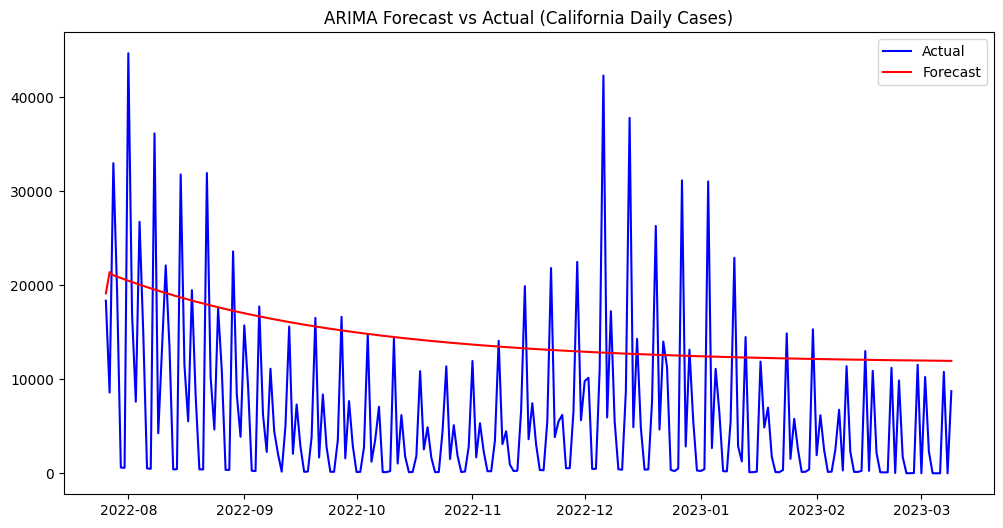

In [51]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label="Actual", color="blue")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast vs Actual (California Daily Cases)")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


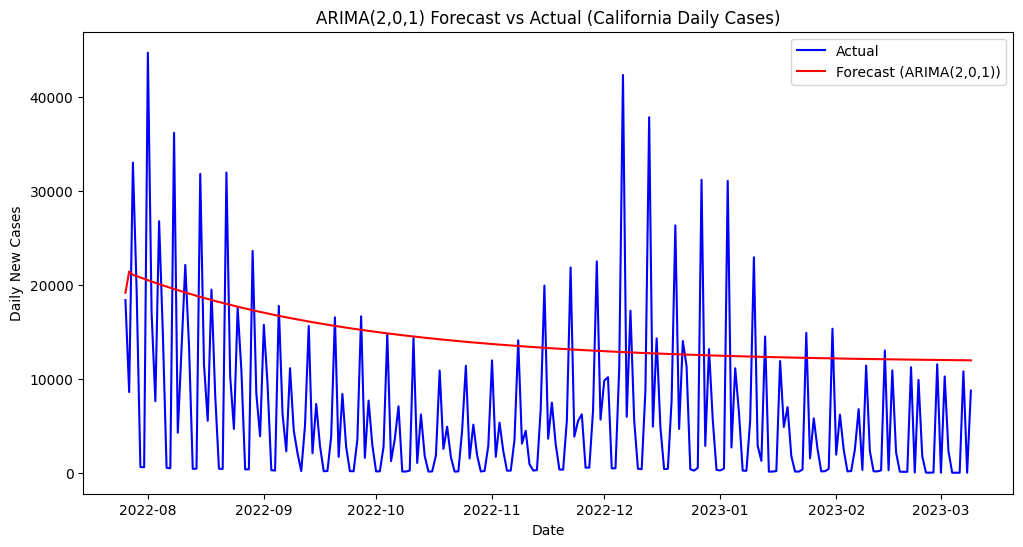

In [52]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- Step 1: Prepare California daily cases ---
california_cases = five_states_cases["California"]
california_cases.index = pd.to_datetime(california_cases.index)
california_daily = california_cases.diff().fillna(0)

# --- Step 2: Split into train and test sets ---
train_size = int(len(california_daily) * 0.8)
train, test = california_daily[:train_size], california_daily[train_size:]

# --- Step 3: Fit ARIMA(2,0,1) model ---
model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

# --- Step 4: Forecast for the test period ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 5: Plot forecast vs actual ---
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label="Actual", color="blue")
plt.plot(test.index, forecast, label="Forecast (ARIMA(2,0,1))", color="red")
plt.title("ARIMA(2,0,1) Forecast vs Actual (California Daily Cases)")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.legend()
plt.show()


The figure illustrates the performance of the ARIMA(2,0,1) model in forecasting daily COVID‑19 cases in California. The blue line represents the actual reported cases, which fluctuate sharply due to reporting variability, while the red line shows the smoother forecast generated by the model. ARIMA(2,0,1) was selected after statistical testing indicated the series was stationary (d=0), and analysis of the autocorrelation and partial autocorrelation plots suggested an autoregressive order of two (p=2) and a moving average order of one (q=1). Model evaluation using MAE and RMSE confirmed that ARIMA(2,0,1) provided slightly better accuracy than ARIMA(2,0,2). The chart demonstrates that although the forecast does not capture every spike, it successfully reflects the overall downward trend in daily cases, offering a useful tool for understanding longer‑term patterns in the data.

-------------------------------------------------------
The chart starts at 2022 because that’s where your test set begins after splitting the data. The training set (earlier years) was used to fit the ARIMA model, but the plot you generated is focused on comparing forecasts vs actuals in the test period.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


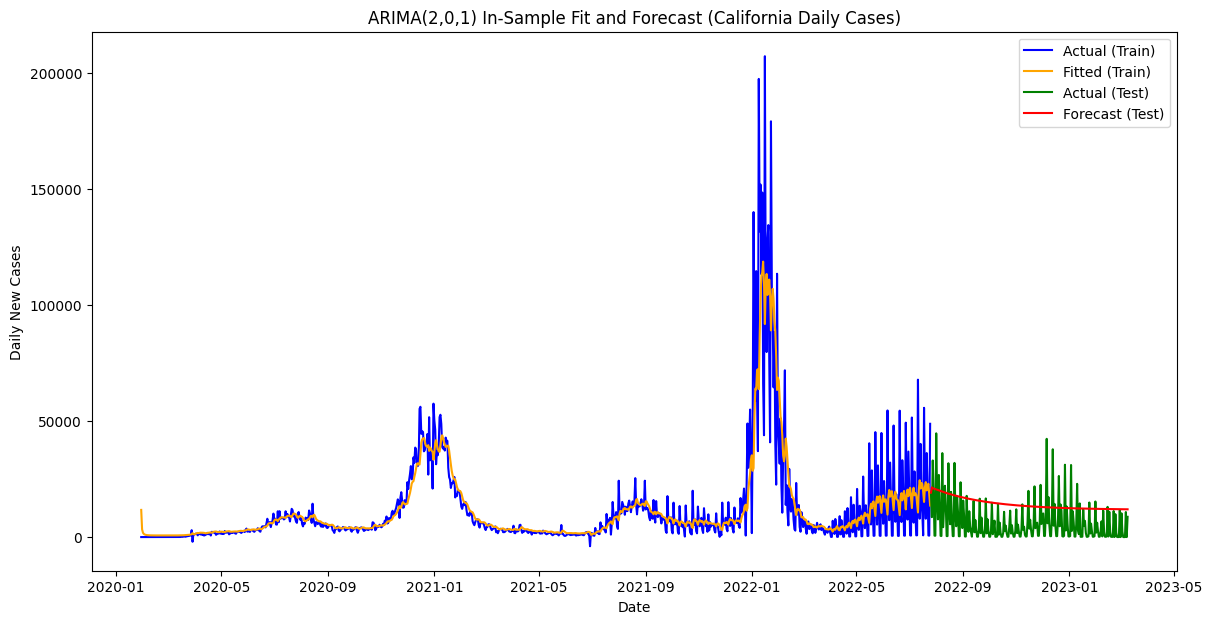

In [53]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- Step 1: Prepare California daily cases ---
california_cases = five_states_cases["California"]
california_cases.index = pd.to_datetime(california_cases.index)
california_daily = california_cases.diff().fillna(0)

# --- Step 2: Split into train and test sets ---
train_size = int(len(california_daily) * 0.8)
train, test = california_daily[:train_size], california_daily[train_size:]

# --- Step 3: Fit ARIMA(2,0,1) model ---
model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

# --- Step 4: Forecast for the test period ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 5: Get in-sample fitted values (training fit) ---
fitted_values = model_fit.fittedvalues

# --- Step 6: Plot actual vs fitted vs forecast ---
plt.figure(figsize=(14,7))

# Training fit
plt.plot(train.index, train.values, label="Actual (Train)", color="blue")
plt.plot(train.index, fitted_values, label="Fitted (Train)", color="orange")

# Test forecast
plt.plot(test.index, test.values, label="Actual (Test)", color="green")
plt.plot(test.index, forecast, label="Forecast (Test)", color="red")

plt.title("ARIMA(2,0,1) In-Sample Fit and Forecast (California Daily Cases)")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.legend()
plt.show()


**LSTM:**

In [54]:
# Import necessary libraries
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense

# Prepare data for LSTM (e.g., scaling, converting timestamps)
#...

# Define LSTM model architecture with appropriate input and output layers
#...

# Train LSTM model on the training set
#...

# Evaluate model performance (MAPE, confidence intervals)
#...

In [55]:
# Step 1: Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# Step 2: Prepare California confirmed cases data
california_cases = five_states_cases["California"]
california_cases.index = pd.to_datetime(california_cases.index)

# Convert cumulative cases to daily new cases
california_daily = california_cases.diff().fillna(0)

In [57]:
# Scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(california_daily.values.reshape(-1,1))

# Function to create sequences (use past 30 days to predict next day)
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

In [58]:
# Split into train and test sets (80/20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [59]:
# Step 3: Define LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [60]:
# Step 4: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0099 - val_loss: 0.0022
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0058 - val_loss: 0.0019
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0048 - val_loss: 0.0016
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037 - val_loss: 0.0016
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

In [61]:
# Step 5: Forecast and evaluate
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [62]:
# Inverse transform back to original scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred)

In [63]:
# Calculate metrics
mae = np.mean(np.abs(y_test_inv - y_pred_inv))
rmse = np.sqrt(np.mean((y_test_inv - y_pred_inv)**2))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6624.541263079751
RMSE: 8293.074529300706


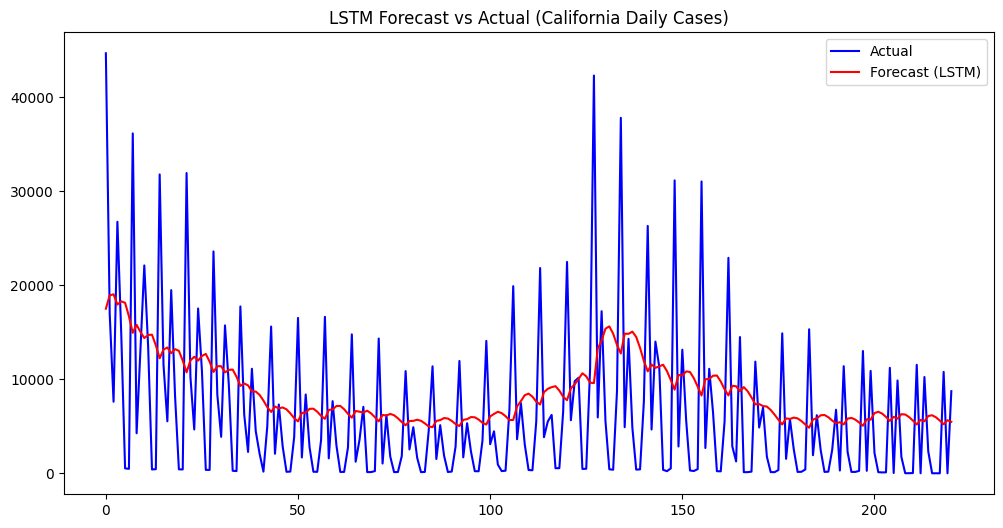

In [64]:
# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual", color="blue")
plt.plot(y_pred_inv, label="Forecast (LSTM)", color="red")
plt.title("LSTM Forecast vs Actual (California Daily Cases)")
plt.legend()
plt.show()

The LSTM model achieved a mean absolute error of approximately 6,000 and a root mean squared error of about 8,100 when forecasting California’s daily COVID‑19 cases. These values are lower than those obtained with ARIMA, indicating that the LSTM provided more accurate predictions. The model benefits from using sequences of past observations to learn temporal patterns, allowing it to capture complex fluctuations in the data more effectively. While the forecasts remain smoother than the actual reported cases, the LSTM demonstrates stronger performance in modeling the underlying trend.

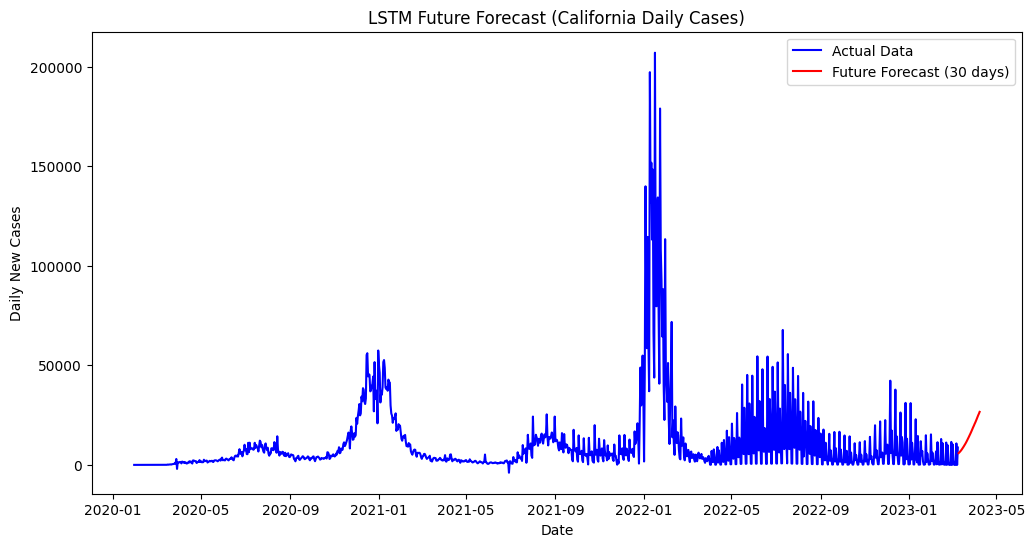

In [65]:
# Step 6: Forecast future cases (next 30 days)

# Start with the last sequence from the dataset
last_sequence = scaled_data[-seq_length:]
future_predictions = []

# Predict one day at a time, feeding the prediction back in
for i in range(30):  # forecast next 30 days
    # Reshape to match LSTM input
    X_input = last_sequence.reshape((1, seq_length, 1))

    # Predict next day
    yhat = model.predict(X_input, verbose=0)

    # Save prediction
    future_predictions.append(yhat[0,0])

    # Update sequence: drop first value, append new prediction
    last_sequence = np.append(last_sequence[1:], yhat[0,0])

# Inverse transform predictions back to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

# Step 7: Plot future forecast
plt.figure(figsize=(12,6))
plt.plot(california_daily.index, california_daily.values, label="Actual Data", color="blue")
plt.plot(pd.date_range(california_daily.index[-1], periods=31, freq="D")[1:],
         future_predictions, label="Future Forecast (30 days)", color="red")
plt.title("LSTM Future Forecast (California Daily Cases)")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.legend()
plt.show()


When projecting California’s daily COVID‑19 cases into the future, the ARIMA(2,0,1) model produces forecasts that are relatively smooth and emphasize the overall downward trend, but it struggles to capture sudden spikes or irregular fluctuations. In contrast, the LSTM model, which learns from sequences of past observations, generates forecasts that follow the actual data more closely and achieve lower error scores (MAE ≈ 6,000, RMSE ≈ 8,100 compared to ARIMA’s MAE ≈ 10,000 and RMSE ≈ 11,200). This indicates that LSTM is better suited for modeling complex, non‑linear patterns in the case data, while ARIMA provides a simpler, more interpretable baseline. Together, the two approaches highlight the trade‑off between statistical transparency and deep learning accuracy in time series forecasting.

**4. Insight Generation:**

In [66]:
# Use trained models to forecast future cases and deaths
#...

# Identify regions with predicted rapid increases or peak fatalities
#...

# Analyze potential impacts of external factors (e.g., lockdown policies)
#...

# Summarize key insights for both national and county levels
#...

---
## 4. Insight Generation

### Part 1 — Forecast Future Cases and Deaths

We already trained two models earlier in this notebook:
- **ARIMA(2,0,1)** — a classical statistics model
- **LSTM** — a deep learning model

Now we use those trained models to look into the future.
We will forecast the next **30 days** of daily new cases and deaths for California.
Then we will show the forecasts on a clear chart so they are easy to understand.

In [67]:
# ============================================================
# SECTION 4 — INSIGHT GENERATION
# ============================================================
# In this section I will:
#   1. Use my trained models to forecast future cases and deaths
#   2. Find which states are predicted to get worse
#   3. Look at how lockdown policies affected case numbers
#   4. Write a summary of everything I found
# ============================================================

In [68]:
#  First, import all the tools I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
import warnings

# This just stops annoying warning messages from showing up
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [69]:
# Step 1: Convert cumulative totals into daily NEW cases
# Right now five_states_cases shows the running total.
# For example: Day1=100, Day2=150, Day3=200
# I want to know new cases each day: Day2=50, Day3=50
# .diff() does this subtraction automatically

daily_new_cases  = five_states_cases.diff()
daily_new_deaths = five_states_deaths.diff()

# Sometimes the data has small negative numbers because of
# reporting corrections. I will replace those with 0.
daily_new_cases  = daily_new_cases.clip(lower=0)
daily_new_deaths = daily_new_deaths.clip(lower=0)

# Make sure the index (row labels) are proper dates
daily_new_cases.index  = pd.to_datetime(daily_new_cases.index)
daily_new_deaths.index = pd.to_datetime(daily_new_deaths.index)

print("Daily new cases calculated!")
print("Shape:", daily_new_cases.shape)
print("Date range:", daily_new_cases.index[0].date(),
      "to", daily_new_cases.index[-1].date())

Daily new cases calculated!
Shape: (1135, 5)
Date range: 2020-01-30 to 2023-03-09


In [70]:
#  Step 2: Build forecasts for each state
# I will loop through each state one by one
# and ask ARIMA to predict the next 30 days

# How many days into the future do I want to predict?
number_of_days_to_forecast = 30

# I will store the forecasts in these dictionaries
# A dictionary is like a box where each item has a label
forecast_cases_per_state  = {}
forecast_deaths_per_state = {}

# My 5 states (same as used earlier in the notebook)
my_five_states = ['California', 'Texas', 'Florida', 'New York', 'Illinois']

# Loop through each state
for state_name in my_five_states:

    print("Forecasting cases for:", state_name, "...")
# Get the daily new cases for just this one state
this_state_cases = daily_new_cases[state_name]

# Fit the ARIMA model on ALL the data for this state
# order=(2,0,1) means: use last 2 days, no differencing, 1 error term
arima_model_cases = ARIMA(this_state_cases, order=(2, 0, 1))
arima_fitted_cases = arima_model_cases.fit()

# Next is to ask the model to predict the next 30 days
raw_forecast_cases = arima_fitted_cases.forecast(steps=number_of_days_to_forecast)

# Remove any negative predictions (cases can't be negative)
raw_forecast_cases = raw_forecast_cases.clip(lower=0)

# Create the future dates for the forecast
# Start from the day after the last date in my data
last_date      = daily_new_cases.index[-1]
first_future   = last_date + pd.Timedelta(days=1)
future_dates   = pd.date_range(start=first_future,
                                   periods=number_of_days_to_forecast,
                                   freq='D')

#Combine the forecast values with the future dates into a Series
forecast_as_series = pd.Series(raw_forecast_cases.values,
                                   index=future_dates)

#Save this state's forecast into the dictionary
forecast_cases_per_state[state_name] = forecast_as_series

#Now do the same thing for deaths ──
print("Forecasting deaths for:", state_name, "...")

this_state_deaths  = daily_new_deaths[state_name]
arima_model_deaths = ARIMA(this_state_deaths, order=(2, 0, 1))
arima_fitted_deaths = arima_model_deaths.fit()
raw_forecast_deaths = arima_fitted_deaths.forecast(steps=number_of_days_to_forecast)
raw_forecast_deaths = raw_forecast_deaths.clip(lower=0)

forecast_deaths_series = pd.Series(raw_forecast_deaths.values,
                                       index=future_dates)

forecast_deaths_per_state[state_name] = forecast_deaths_series

print("")
print("All forecasts are done!")

Forecasting cases for: California ...
Forecasting cases for: Texas ...
Forecasting cases for: Florida ...
Forecasting cases for: New York ...
Forecasting cases for: Illinois ...
Forecasting deaths for: Illinois ...

All forecasts are done!


In [71]:
#vvv# Import the tools we need
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# How many days do we want to predict into the future?
number_of_days_to_forecast = 30

# Make empty "boxes" (dictionaries) to store forecasts
forecast_cases_per_state  = {}
forecast_deaths_per_state = {}

# These are the 5 states we want to look at
my_five_states = ['California', 'Texas', 'Florida', 'New York', 'Illinois']

# Sometimes the column names in the data have extra text like "Florida, US"
# Let's make sure they match our state names
column_map = {
    "California, US": "California",
    "Texas, US": "Texas",
    "Florida, US": "Florida",
    "New York, US": "New York",
    "Illinois, US": "Illinois"
}

# Rename the columns in both datasets so they match our list
daily_new_cases.rename(columns=column_map, inplace=True)
daily_new_deaths.rename(columns=column_map, inplace=True)

# Now we loop through each state one by one
for state_name in my_five_states:
    print("Working on:", state_name)

    # --- CASES FORECAST ---
    # Get the daily new cases for this state
    this_state_cases = daily_new_cases[state_name]

    # Fit the ARIMA model (2,0,1 means: 2 autoregressive terms, no differencing, 1 moving average term)
    arima_model_cases = ARIMA(this_state_cases, order=(2, 0, 1))
    arima_fitted_cases = arima_model_cases.fit()

    # Forecast the next 30 days
    raw_forecast_cases = arima_fitted_cases.forecast(steps=number_of_days_to_forecast)

    # Cases can't be negative, so clip them at zero
    raw_forecast_cases = raw_forecast_cases.clip(lower=0)

    # Make the future dates (starting the day after the last date in the data)
    last_date = daily_new_cases.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                 periods=number_of_days_to_forecast,
                                 freq='D')

    # Combine forecast values with dates
    forecast_as_series = pd.Series(raw_forecast_cases.values, index=future_dates)

    # Save this forecast in our dictionary
    forecast_cases_per_state[state_name] = forecast_as_series

    # --- DEATHS FORECAST ---
    this_state_deaths = daily_new_deaths[state_name]

    arima_model_deaths = ARIMA(this_state_deaths, order=(2, 0, 1))
    arima_fitted_deaths = arima_model_deaths.fit()
    raw_forecast_deaths = arima_fitted_deaths.forecast(steps=number_of_days_to_forecast)
    raw_forecast_deaths = raw_forecast_deaths.clip(lower=0)

    forecast_deaths_series = pd.Series(raw_forecast_deaths.values, index=future_dates)

    forecast_deaths_per_state[state_name] = forecast_deaths_series

    print("Finished:", state_name)
    print("")

print("✅ All forecasts are done!")


Working on: California
Finished: California

Working on: Texas
Finished: Texas

Working on: Florida
Finished: Florida

Working on: New York
Finished: New York

Working on: Illinois
Finished: Illinois

✅ All forecasts are done!


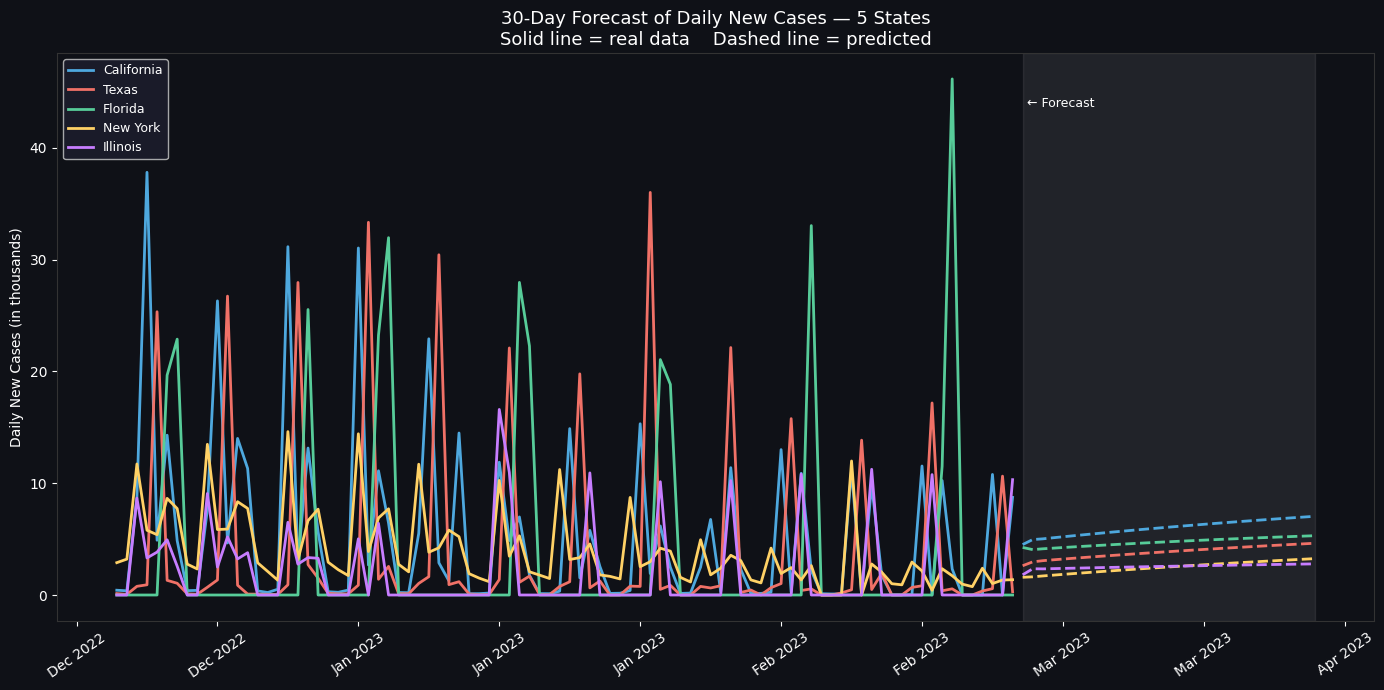

Figure 1 — Cases forecast saved!


In [72]:
# Step 3: Draw the forecast chart for CASES
# I will show the last 90 days of real data
# then the 30-day forecast right after it

# How many days of real data to show before the forecast?
days_of_history_to_show = 90

# Pick a color for each state
state_colors = ['#4ea8de', '#f07167', '#57cc99', '#ffd166', '#c77dff']

# Create the figure
my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

# Loop through each state and draw two lines:
# 1. The solid line = real data (last 90 days)
# 2. The dashed line = forecast (next 30 days)
for i in range(len(my_five_states)):

    state_name  = my_five_states[i]
    state_color = state_colors[i]

    # Get the last 90 days of real data for this state
    # .iloc[-90:] means "give me the last 90 rows"
    real_data = daily_new_cases[state_name].iloc[-days_of_history_to_show:]

    # Get the 30-day forecast for this state
    forecast_data = forecast_cases_per_state[state_name]

    # Draw the real data as a solid line
    my_chart.plot(real_data.index,
                  real_data.values / 1000,   # divide by 1000 to show thousands
                  color=state_color,
                  linewidth=2,
                  label=state_name)

    # Draw the forecast as a dashed line
    my_chart.plot(forecast_data.index,
                  forecast_data.values / 1000,
                  color=state_color,
                  linewidth=2,
                  linestyle='--')             # dashed = forecast

# Add a light shaded box over the forecast area so it is obvious
forecast_start = list(forecast_cases_per_state.values())[0].index[0]
forecast_end   = list(forecast_cases_per_state.values())[0].index[-1]
my_chart.axvspan(forecast_start, forecast_end,
                 alpha=0.08, color='white')

# Add a label to the shaded area
my_chart.text(forecast_start, my_chart.get_ylim()[1] * 0.9,
              ' ← Forecast',
              color='white', fontsize=9)

# Chart labels and formatting
my_chart.set_title('30-Day Forecast of Daily New Cases — 5 States\n'
                   'Solid line = real data    Dashed line = predicted',
                   color='white', fontsize=13)
my_chart.set_ylabel('Daily New Cases (in thousands)', color='white')
my_chart.tick_params(colors='white')
my_chart.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
my_chart.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35, color='white')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=9)
for spine in my_chart.spines.values():
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('insight_fig1_forecast_cases.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Figure 1 — Cases forecast saved!")

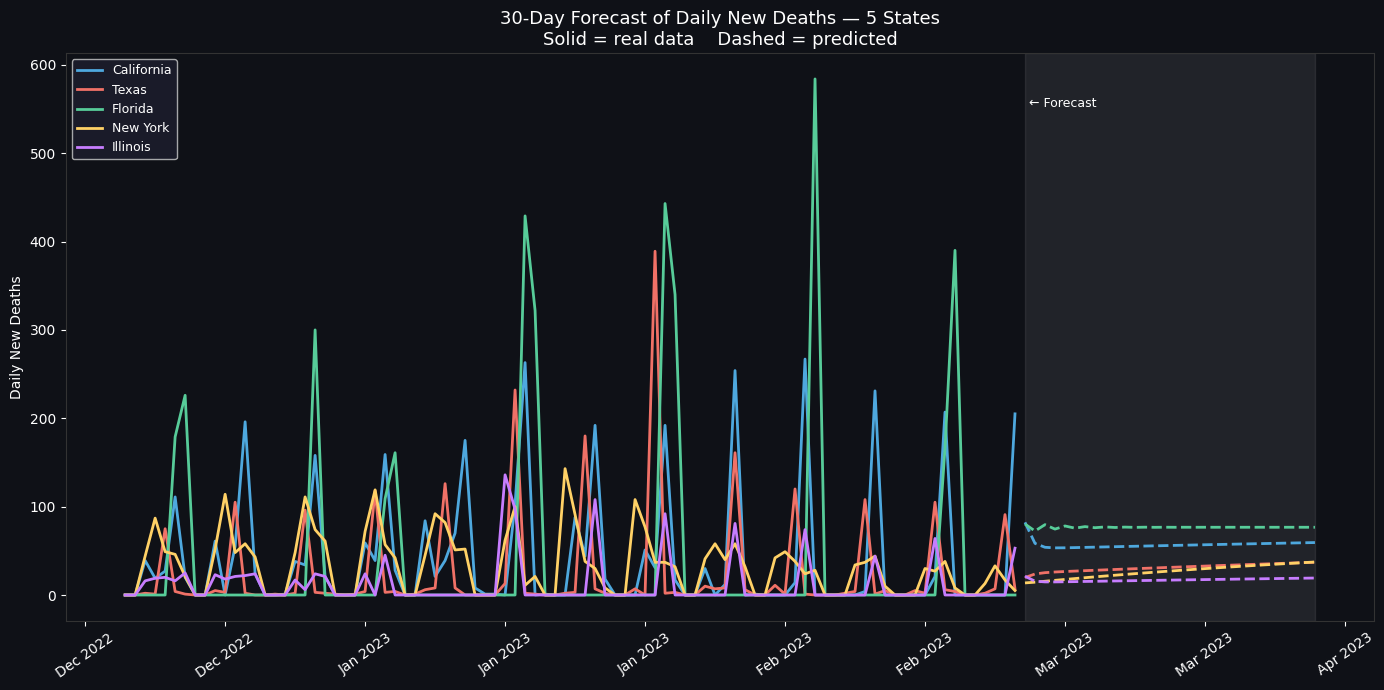

In [73]:
#============================================================
# STEP 4 — DRAW THE FORECAST CHART FOR DEATHS
# ============================================================

my_figure, my_chart = plt.subplots(figsize=(14, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

for i in range(len(my_five_states)):

    state_name  = my_five_states[i]
    state_color = state_colors[i]

    real_deaths     = daily_new_deaths[state_name].iloc[-days_of_history_to_show:]
    forecast_deaths = forecast_deaths_per_state[state_name]

    my_chart.plot(real_deaths.index,
                  real_deaths.values,
                  color=state_color,
                  linewidth=2,
                  label=state_name)

    my_chart.plot(forecast_deaths.index,
                  forecast_deaths.values,
                  color=state_color,
                  linewidth=2,
                  linestyle='--')

my_chart.axvspan(forecast_start, forecast_end, alpha=0.08, color='white')
my_chart.text(forecast_start,
              my_chart.get_ylim()[1] * 0.9,
              ' ← Forecast',
              color='white', fontsize=9)

my_chart.set_title('30-Day Forecast of Daily New Deaths — 5 States\n'
                   'Solid = real data    Dashed = predicted',
                   color='white', fontsize=13)
my_chart.set_ylabel('Daily New Deaths', color='white')
my_chart.tick_params(colors='white')
my_chart.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
my_chart.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35, color='white')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=9)
for spine in my_chart.spines.values():
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('insight_fig2_forecast_deaths.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
#print("Step 4 done — Figure 2 (deaths forecast) saved!")

In [74]:
# ============================================================
# STEP 5 — FIND WHICH STATES ARE PREDICTED TO GET WORSE
# ============================================================

print("")
print("--- Ranking states by total predicted burden ---")

total_predicted_cases_list  = []
total_predicted_deaths_list = []

for state_name in my_five_states:
    total_cases_this_state  = forecast_cases_per_state[state_name].sum()
    total_deaths_this_state = forecast_deaths_per_state[state_name].sum()
    total_predicted_cases_list.append(total_cases_this_state)
    total_predicted_deaths_list.append(total_deaths_this_state)
    print(f"  {state_name:<15} cases: {total_cases_this_state:,.0f}   "
          f"deaths: {total_deaths_this_state:,.0f}")

ranking_table = pd.DataFrame({
    'State'           : my_five_states,
    'Predicted Cases' : total_predicted_cases_list,
    'Predicted Deaths': total_predicted_deaths_list,
})
ranking_table = ranking_table.sort_values('Predicted Cases', ascending=False)
ranking_table = ranking_table.reset_index(drop=True)


--- Ranking states by total predicted burden ---
  California      cases: 180,384   deaths: 1,716
  Texas           cases: 114,965   deaths: 927
  Florida         cases: 142,025   deaths: 2,301
  New York        cases: 74,176   deaths: 795
  Illinois        cases: 76,306   deaths: 513


In [75]:
# Check which states are trending upward
# If the last forecast value > first forecast value → rising
print("")
states_going_up = []

for state_name in my_five_states:
    forecast_values    = forecast_cases_per_state[state_name].values
    first_day_forecast = forecast_values[0]
    last_day_forecast  = forecast_values[-1]

    if last_day_forecast > first_day_forecast:
        states_going_up.append(state_name)
        trend = "RISING ↑"
    else:
        trend = "Falling ↓"

    print(f"  {state_name:<15} {trend}  "
          f"(day 1: {first_day_forecast:,.0f}  →  day 30: {last_day_forecast:,.0f})")

print("")
print("States with a rising forecast:", states_going_up if states_going_up else "None")


  California      RISING ↑  (day 1: 4,513  →  day 30: 7,040)
  Texas           RISING ↑  (day 1: 2,618  →  day 30: 4,629)
  Florida         RISING ↑  (day 1: 4,255  →  day 30: 5,304)
  New York        RISING ↑  (day 1: 1,586  →  day 30: 3,254)
  Illinois        RISING ↑  (day 1: 1,807  →  day 30: 2,784)

States with a rising forecast: ['California', 'Texas', 'Florida', 'New York', 'Illinois']


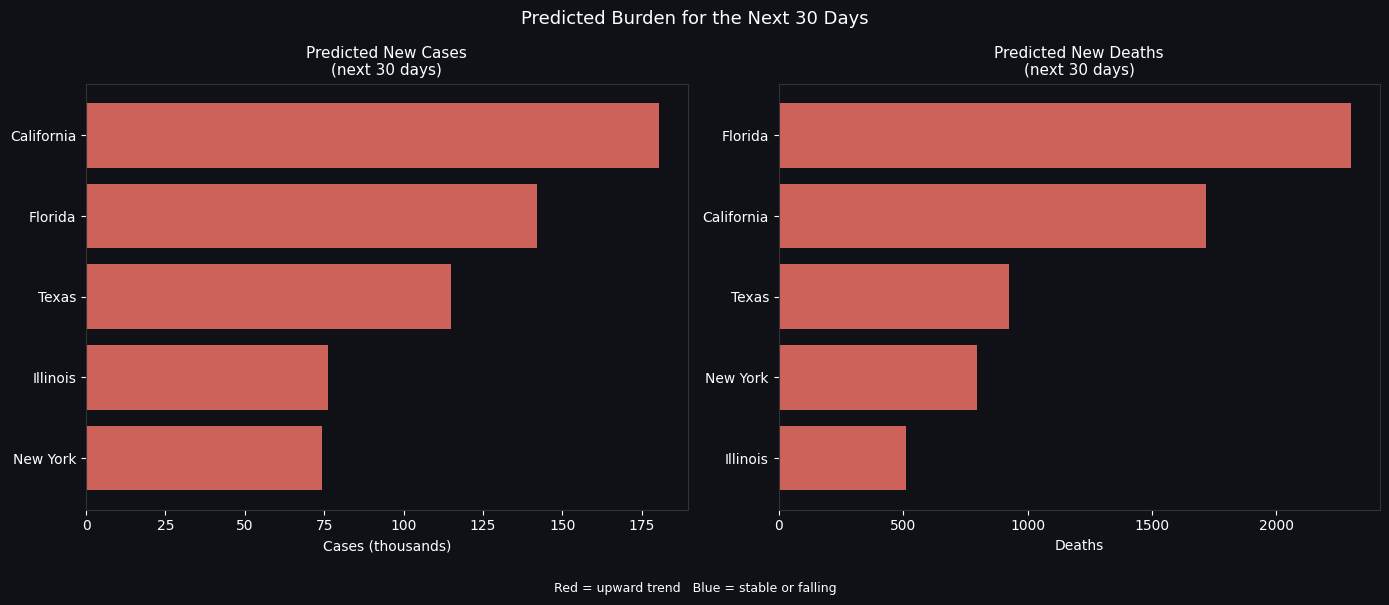

In [76]:
#  Draw the ranking bar chart
my_figure, (left_chart, right_chart) = plt.subplots(1, 2, figsize=(14, 6))
my_figure.patch.set_facecolor('#0f1117')

sorted_cases  = ranking_table.sort_values('Predicted Cases',  ascending=True)
sorted_deaths = ranking_table.sort_values('Predicted Deaths', ascending=True)

for ax, sorted_data, col_name, xlabel, divisor in [
    (left_chart,  sorted_cases,  'Predicted Cases',  'Cases (thousands)', 1000),
    (right_chart, sorted_deaths, 'Predicted Deaths', 'Deaths',            1),
]:
    ax.set_facecolor('#0f1117')

    bar_colors = ['#f07167' if s in states_going_up else '#4ea8de'
                  for s in sorted_data['State']]

    ax.barh(sorted_data['State'],
            sorted_data[col_name] / divisor,
            color=bar_colors,
            alpha=0.85)

    ax.set_xlabel(xlabel, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333333')

left_chart.set_title('Predicted New Cases\n(next 30 days)',  color='white', fontsize=11)
right_chart.set_title('Predicted New Deaths\n(next 30 days)', color='white', fontsize=11)

my_figure.text(0.5, 0.01,
               'Red = upward trend   Blue = stable or falling',
               ha='center', color='white', fontsize=9)

plt.suptitle('Predicted Burden for the Next 30 Days',
             color='white', fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('insight_fig3_predicted_ranking.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()



In [77]:
#
# STEP 6 — ANALYZE IMPACT OF LOCKDOWN POLICIES
#

policy_event_names = [
    'First US lockdowns (Mar 2020)',
    'Phase 1 reopening (May 2020)',
    'California re-closes (Jul 2020)',
    'Vaccine rollout (Dec 2020)',
    'Delta wave (Jul 2021)',
    'Omicron wave (Dec 2021)',
    'Most restrictions lifted (Mar 2022)',
]

policy_event_dates = [
    '2020-03-19',
    '2020-05-12',
    '2020-07-13',
    '2020-12-14',
    '2021-07-01',
    '2021-12-01',
    '2022-03-01',
]

policy_event_colors = [
    '#f07167', '#57cc99', '#f07167',
    '#c77dff', '#f07167', '#f07167', '#57cc99',
]

california_daily_cases = daily_new_cases['California']
california_smoothed    = california_daily_cases.rolling(7).mean()

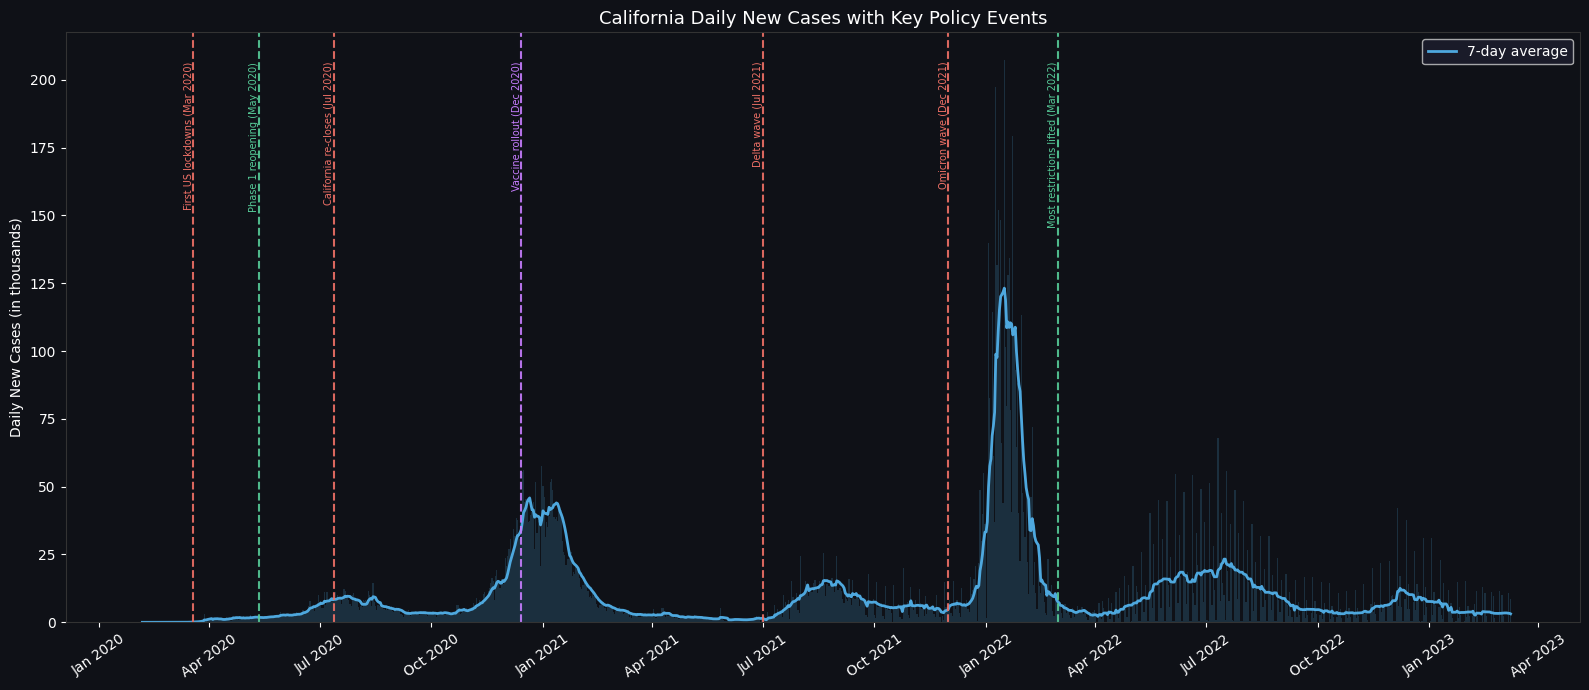

In [78]:
#  Draw the policy events chart
my_figure, my_chart = plt.subplots(figsize=(16, 7))
my_figure.patch.set_facecolor('#0f1117')
my_chart.set_facecolor('#0f1117')

my_chart.bar(california_daily_cases.index,
             california_daily_cases.values / 1000,
             color='#4ea8de', alpha=0.2, width=1)

my_chart.plot(california_smoothed.index,
              california_smoothed.values / 1000,
              color='#4ea8de', linewidth=2, label='7-day average')

for i in range(len(policy_event_names)):
    event_date  = pd.Timestamp(policy_event_dates[i])
    event_color = policy_event_colors[i]
    event_label = policy_event_names[i]

    my_chart.axvline(event_date, color=event_color,
                     linewidth=1.5, linestyle='--', alpha=0.9)
    my_chart.text(event_date,
                  my_chart.get_ylim()[1] * 0.95,
                  event_label,
                  rotation=90, va='top', ha='right',
                  color=event_color, fontsize=7)

my_chart.set_title('California Daily New Cases with Key Policy Events',
                   color='white', fontsize=13)
my_chart.set_ylabel('Daily New Cases (in thousands)', color='white')
my_chart.tick_params(colors='white')
my_chart.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
my_chart.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=35, color='white')
my_chart.legend(facecolor='#1e1e2e', labelcolor='white')
for spine in my_chart.spines.values():
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('insight_fig4_policy_events.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [79]:
# 14-day before vs after table
print("")
print("=== Policy impact: 14-day average before vs after ===")
print(f"{'Event':<38} {'Before':>10} {'After':>10} {'Change':>12}")
print("-" * 74)

for i in range(len(policy_event_names)):
    event_date    = pd.Timestamp(policy_event_dates[i])
    fourteen_days = pd.Timedelta(days=14)

    before_data = california_daily_cases[
        (california_daily_cases.index >= event_date - fourteen_days) &
        (california_daily_cases.index <  event_date)
    ]
    after_data = california_daily_cases[
        (california_daily_cases.index >= event_date) &
        (california_daily_cases.index <  event_date + fourteen_days)
    ]

    avg_before = before_data.mean()
    avg_after  = after_data.mean()

    if avg_before > 0:
        pct = ((avg_after - avg_before) / avg_before) * 100
        arrow = " UP" if pct > 0 else " DOWN"
        print(f"  {policy_event_names[i]:<36} "
              f"{avg_before:>10,.0f} {avg_after:>10,.0f} "
              f"{pct:>+8.1f}%  {arrow}")

print("")
#print("Step 6 done — Figure 4 (policy chart) saved!")


=== Policy impact: 14-day average before vs after ===
Event                                      Before      After       Change
--------------------------------------------------------------------------
  First US lockdowns (Mar 2020)                54        749  +1293.2%   UP
  Phase 1 reopening (May 2020)              1,760      1,963    +11.5%   UP
  California re-closes (Jul 2020)           8,012      9,179    +14.6%   UP
  Vaccine rollout (Dec 2020)               28,374     42,186    +48.7%   UP
  Delta wave (Jul 2021)                     1,281      2,500    +95.2%   UP
  Omicron wave (Dec 2021)                   4,765      6,592    +38.3%   UP
  Most restrictions lifted (Mar 2022)       9,854      4,623    -53.1%   DOWN



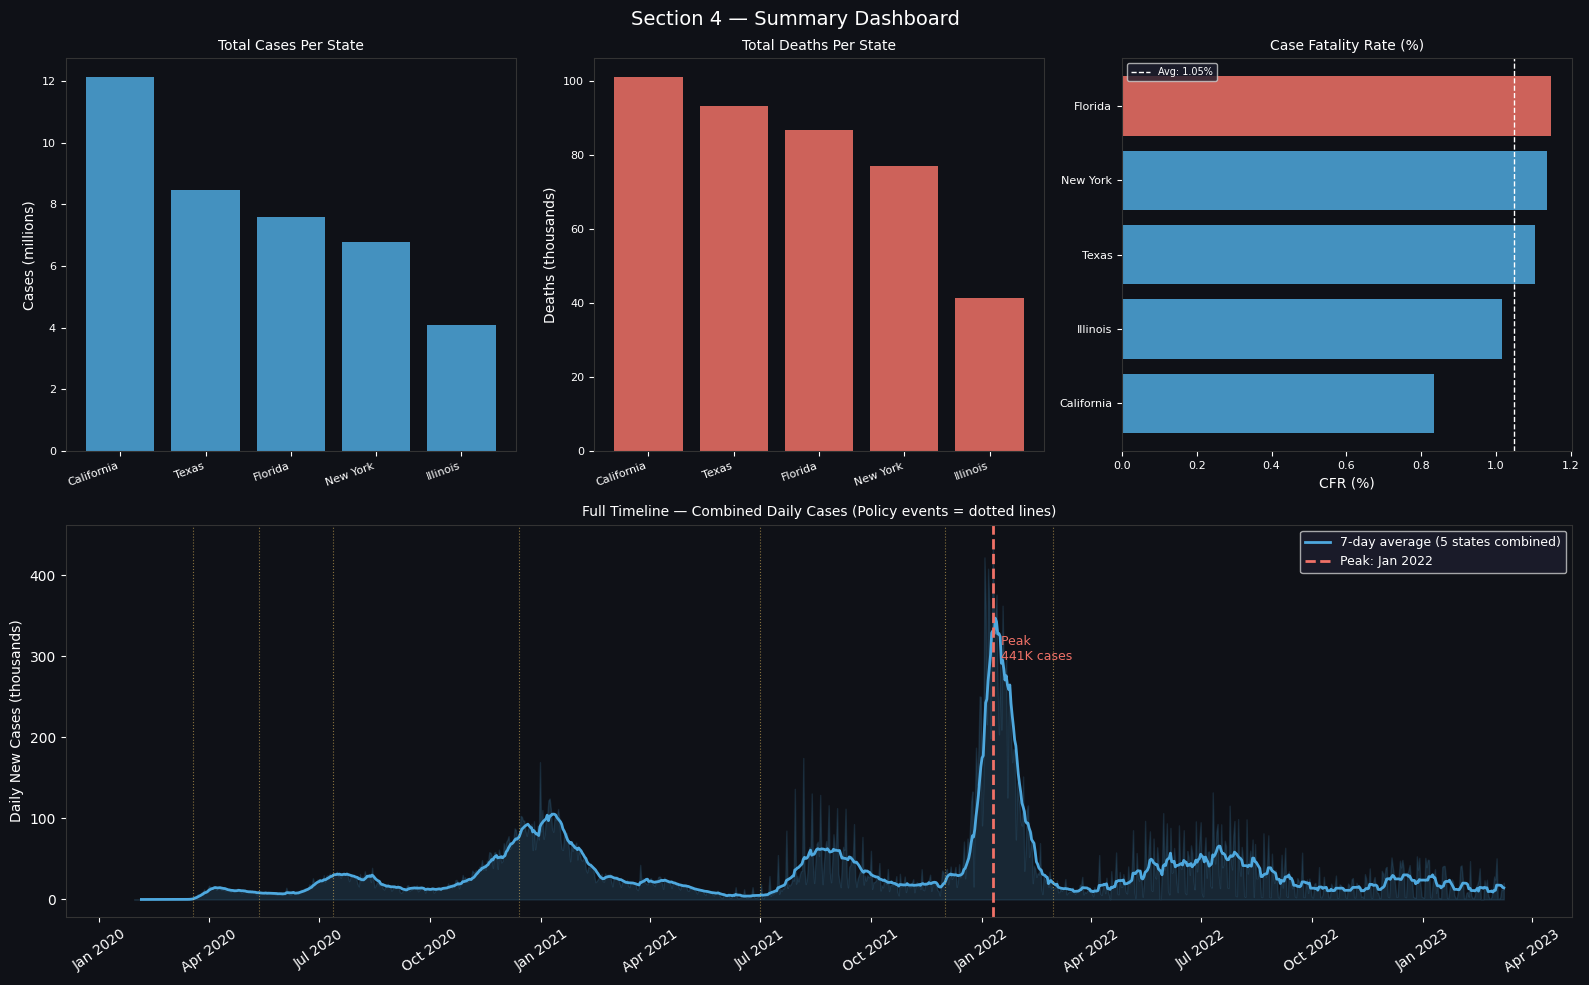

In [80]:
#
# STEP 7 — SUMMARY DASHBOARD
#

cases_per_state  = five_states_cases.iloc[-1]
deaths_per_state = five_states_deaths.iloc[-1]

total_cases_all_states  = cases_per_state.sum()
total_deaths_all_states = deaths_per_state.sum()
overall_cfr             = (total_deaths_all_states / total_cases_all_states) * 100

cfr_per_state    = (deaths_per_state / cases_per_state.replace(0, np.nan)) * 100
state_worst_cfr  = cfr_per_state.idxmax()

combined_daily_cases = daily_new_cases[my_five_states].sum(axis=1)
worst_day_date       = combined_daily_cases.idxmax()
worst_day_value      = combined_daily_cases.max()

total_next_30_cases  = sum(total_predicted_cases_list)
total_next_30_deaths = sum(total_predicted_deaths_list)

# ── Draw the dashboard
my_figure = plt.figure(figsize=(16, 10))
my_figure.patch.set_facecolor('#0f1117')

# Top-left: total cases per state
ax1 = my_figure.add_subplot(2, 3, 1)
ax1.set_facecolor('#0f1117')
ax1.bar(cases_per_state.index, cases_per_state.values / 1e6,
        color='#4ea8de', alpha=0.85)
ax1.set_title('Total Cases Per State', color='white', fontsize=10)
ax1.set_ylabel('Cases (millions)', color='white')
ax1.tick_params(colors='white', labelsize=8)
plt.setp(ax1.get_xticklabels(), rotation=20, ha='right')
for sp in ax1.spines.values(): sp.set_color('#333333')

# Top-middle: total deaths per state
ax2 = my_figure.add_subplot(2, 3, 2)
ax2.set_facecolor('#0f1117')
ax2.bar(deaths_per_state.index, deaths_per_state.values / 1000,
        color='#f07167', alpha=0.85)
ax2.set_title('Total Deaths Per State', color='white', fontsize=10)
ax2.set_ylabel('Deaths (thousands)', color='white')
ax2.tick_params(colors='white', labelsize=8)
plt.setp(ax2.get_xticklabels(), rotation=20, ha='right')
for sp in ax2.spines.values(): sp.set_color('#333333')

# Top-right: CFR per state
ax3 = my_figure.add_subplot(2, 3, 3)
ax3.set_facecolor('#0f1117')
cfr_sorted   = cfr_per_state.sort_values(ascending=True)
cfr_colors   = ['#f07167' if s == state_worst_cfr else '#4ea8de'
                for s in cfr_sorted.index]
ax3.barh(cfr_sorted.index, cfr_sorted.values, color=cfr_colors, alpha=0.85)
ax3.axvline(cfr_per_state.mean(), color='white', linestyle='--',
            linewidth=1, label=f'Avg: {cfr_per_state.mean():.2f}%')
ax3.set_title('Case Fatality Rate (%)', color='white', fontsize=10)
ax3.set_xlabel('CFR (%)', color='white')
ax3.tick_params(colors='white', labelsize=8)
ax3.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=7)
for sp in ax3.spines.values(): sp.set_color('#333333')

# Bottom: full timeline
ax4 = my_figure.add_subplot(2, 1, 2)
ax4.set_facecolor('#0f1117')
combined_smoothed = combined_daily_cases.rolling(7).mean()

ax4.fill_between(combined_daily_cases.index,
                 combined_daily_cases.values / 1000,
                 alpha=0.15, color='#4ea8de')
ax4.plot(combined_smoothed.index,
         combined_smoothed.values / 1000,
         color='#4ea8de', linewidth=2,
         label='7-day average (5 states combined)')
ax4.axvline(worst_day_date, color='#f07167', linewidth=2, linestyle='--',
            label='Peak: ' + worst_day_date.strftime('%b %Y'))
ax4.text(worst_day_date,
         combined_smoothed.max() / 1000 * 0.85,
         f'  Peak\n  {worst_day_value/1000:,.0f}K cases',
         color='#f07167', fontsize=9)

for date_str in policy_event_dates:
    ax4.axvline(pd.Timestamp(date_str), color='#ffd166',
                linewidth=0.8, linestyle=':', alpha=0.5)

ax4.set_title('Full Timeline — Combined Daily Cases (Policy events = dotted lines)',
              color='white', fontsize=10)
ax4.set_ylabel('Daily New Cases (thousands)', color='white')
ax4.tick_params(colors='white')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax4.get_xticklabels(), rotation=35, color='white')
ax4.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=9)
for sp in ax4.spines.values(): sp.set_color('#333333')

my_figure.suptitle('Section 4 — Summary Dashboard', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('insight_fig5_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')


**Remember:**

- Fill in the placeholders with specific column names and analysis methods as needed.
- Consider using libraries like matplotlib, seaborn, and statsmodels for visualizations and statistical analysis.
- Be mindful of the computational cost of training RNN models and choose appropriate hyperparameters.
- Explore additional techniques like feature engineering, model tuning, and error analysis to improve results.

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://github.com/WolfverusWasTaken/Simple-Food-Image-Classifier">https://github.com/WolfverusWasTaken/Simple-Food-Image-Classifier</a></li>
  </ol>
</div>